# Class 11b: Spectral Properties and Linear Algebra, Part 1

**CNET 5052 — Spring 2026**


---

By the end of this class you will be able to:

1. Read the Fiedler value and Fiedler vector as concrete signals of bottlenecks and connectivity.
2. Explain what the spectral gap means for Laplacians and for random walks, and connect it to mixing.
3. Use eigenmodes to understand diffusion, consensus, and epidemic thresholds on networks.
4. Build a spectral clustering pipeline from scratch: eigenvectors first, then $k$-means.
5. Use Laplacian and random-walk eigenvectors as coordinates for embedding and graph drawing.
6. Explain what the non-backtracking matrix is, why backtracking creates trouble on sparse graphs, and why the Bethe Hessian helps.
7. Avoid the practical traps that make spectral methods look worse than they really are.


---

1. Come in. Sit down. Open Teams.
2. Find your notebook in your `/Class_11/` folder.

In [1]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from scipy.optimize import linear_sum_assignment
from IPython.display import display

rng = np.random.default_rng(5052)
np.set_printoptions(precision=4, suppress=True)


In [2]:

def stable_nodelist(G, nodelist=None):
    return list(G.nodes()) if nodelist is None else list(nodelist)


def adjacency_dense(G, nodelist=None, weight=None, dtype=float):
    nodes = stable_nodelist(G, nodelist)
    if hasattr(nx, "to_numpy_array"):
        A = nx.to_numpy_array(G, nodelist=nodes, weight=weight, dtype=dtype)
    else:
        A = np.asarray(nx.adjacency_matrix(G, nodelist=nodes, weight=weight).todense(), dtype=dtype)
    return A, nodes


def adjacency_sparse(G, nodelist=None, weight=None, dtype=float):
    nodes = stable_nodelist(G, nodelist)
    if hasattr(nx, "to_scipy_sparse_array"):
        A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight=weight, dtype=dtype, format="csr")
        if not sp.issparse(A):
            A = sp.csr_matrix(A)
    else:
        A = nx.adjacency_matrix(G, nodelist=nodes, weight=weight).astype(dtype).tocsr()
    return A, nodes


def show_matrix_df(M, rows=None, cols=None, precision=2):
    M = np.asarray(M)
    if rows is None:
        rows = range(M.shape[0])
    if cols is None:
        cols = range(M.shape[1])
    df = pd.DataFrame(M, index=rows, columns=cols)
    display(df.round(precision))
    return df


def plot_matrix_heatmap(M, ax=None, title=None, cmap="viridis", xticklabels=None, yticklabels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
    im = ax.imshow(np.asarray(M), cmap=cmap)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    if title is not None:
        ax.set_title(title)
    if xticklabels is not None:
        ax.set_xticks(range(len(xticklabels)))
        ax.set_xticklabels(xticklabels, rotation=90)
    if yticklabels is not None:
        ax.set_yticks(range(len(yticklabels)))
        ax.set_yticklabels(yticklabels)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax


def draw_graph(
    G,
    pos=None,
    ax=None,
    title=None,
    node_values=None,
    node_labels=True,
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    edge_width_scale=1.5,
    edge_alpha=0.8,
    node_size=250,
    font_size=8,
    with_colorbar=False,
    edge_color="#888888",
    edgecolors="black",
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=100)
    if pos is None:
        pos = nx.spring_layout(G, seed=5052)
    nodes = list(G.nodes())
    edges = list(G.edges(data=True))
    widths = [edge_width_scale * d.get("weight", 1.0) for _, _, d in edges]
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=edge_alpha, edge_color=edge_color)
    if node_values is None:
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color="white", edgecolors=edgecolors, node_size=node_size)
    else:
        values = np.asarray([node_values[n] for n in nodes], dtype=float)
        if vmin is None:
            vmin = values.min()
        if vmax is None:
            vmax = values.max()
        coll = nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_color=values,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors=edgecolors,
            node_size=node_size,
        )
        if with_colorbar:
            plt.colorbar(coll, ax=ax, fraction=0.046, pad=0.04)
    if node_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)
    if title is not None:
        ax.set_title(title)
    ax.set_axis_off()
    return ax


def two_clique_positions(left, right, gap=3.0, radius=1.0):
    pos = {}
    for i, u in enumerate(left):
        angle = 2 * np.pi * i / len(left)
        pos[u] = np.array([-gap / 2 + radius * np.cos(angle), radius * np.sin(angle)])
    for i, u in enumerate(right):
        angle = 2 * np.pi * i / len(right)
        pos[u] = np.array([gap / 2 + radius * np.cos(angle), radius * np.sin(angle)])
    return pos


def clique_chain_positions(groups, gap=2.8, radius=0.8):
    pos = {}
    centers = np.linspace(-gap * (len(groups) - 1) / 2, gap * (len(groups) - 1) / 2, len(groups))
    for c, group in zip(centers, groups):
        for i, u in enumerate(group):
            angle = 2 * np.pi * i / len(group)
            pos[u] = np.array([c + radius * np.cos(angle), radius * np.sin(angle)])
    return pos


In [3]:

def degree_vector_from_adjacency(A):
    return np.asarray(A.sum(axis=1)).ravel()


def diag_sparse(x):
    return sp.diags(np.asarray(x, dtype=float), format="csr")


def safe_inv(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x != 0
    out[mask] = 1.0 / x[mask]
    return out


def safe_inv_sqrt(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x > 0
    out[mask] = 1.0 / np.sqrt(x[mask])
    return out


def laplacian_from_adjacency(A):
    d = degree_vector_from_adjacency(A)
    if sp.issparse(A):
        return diag_sparse(d) - A
    return np.diag(d) - A


def normalized_adjacency(A):
    d = degree_vector_from_adjacency(A)
    if sp.issparse(A):
        Dm12 = diag_sparse(safe_inv_sqrt(d))
        return Dm12 @ A @ Dm12
    Dm12 = np.diag(safe_inv_sqrt(d))
    return Dm12 @ A @ Dm12


def normalized_laplacian_sym(A):
    n = A.shape[0]
    if sp.issparse(A):
        return sp.eye(n, format="csr") - normalized_adjacency(A)
    return np.eye(n) - normalized_adjacency(A)


def random_walk_matrix(A):
    d = degree_vector_from_adjacency(A)
    if sp.issparse(A):
        return diag_sparse(safe_inv(d)) @ A
    return np.diag(safe_inv(d)) @ A


def eigsh_sorted(M, k, which="SM"):
    vals, vecs = spla.eigsh(M, k=k, which=which)
    idx = np.argsort(vals)
    return vals[idx], vecs[:, idx]


def eigh_sorted(M):
    vals, vecs = np.linalg.eigh(np.asarray(M, dtype=float))
    idx = np.argsort(vals)
    return vals[idx], vecs[:, idx]


def normalize_sign(v):
    v = np.asarray(v, dtype=float).copy()
    idx = np.argmax(np.abs(v))
    if v[idx] < 0:
        v *= -1
    return v


def laplacian_quadratic_form(L, x):
    x = np.asarray(x, dtype=float).ravel()
    return float(x @ (L @ x))


def conductance(G, S, weight="weight"):
    S = set(S)
    T = set(G.nodes()) - S
    if len(S) == 0 or len(T) == 0:
        return np.inf

    cut = 0.0
    for u, v, d in G.edges(data=True):
        w = d.get(weight, 1.0)
        if (u in S) ^ (v in S):
            cut += w

    volS = sum(dict(G.degree(S, weight=weight)).values())
    volT = sum(dict(G.degree(T, weight=weight)).values())
    denom = min(volS, volT)
    if denom == 0:
        return np.inf
    return cut / denom


def fiedler_sweep_cut(G, values, nodelist, weight="weight"):
    values = np.asarray(values, dtype=float).ravel()
    order = np.argsort(values)
    ordered_nodes = np.asarray(nodelist)

    best_phi = np.inf
    best_S = None
    phis = []
    sets = []

    for k in range(1, len(order)):
        S = set(ordered_nodes[order[:k]])
        phi = conductance(G, S, weight=weight)
        phis.append(phi)
        sets.append(S)
        if phi < best_phi:
            best_phi = phi
            best_S = S

    return best_phi, best_S, np.array(phis), order, sets


def make_lazy(P, beta=0.5):
    n = P.shape[0]
    if sp.issparse(P):
        return beta * sp.eye(n, format="csr") + (1.0 - beta) * P
    return beta * np.eye(n) + (1.0 - beta) * P


def random_walk_tv_distances(G, start, T=40, weight="weight", lazy=True):
    A, nodes = adjacency_sparse(G, weight=weight)
    P = random_walk_matrix(A)
    if lazy:
        P = make_lazy(P, beta=0.5)

    d = degree_vector_from_adjacency(A)
    pi = d / d.sum()

    node_to_i = {u: i for i, u in enumerate(nodes)}
    p = np.zeros(len(nodes))
    p[node_to_i[start]] = 1.0

    tv = [0.5 * np.abs(p - pi).sum()]
    for _ in range(T):
        p = p @ P
        tv.append(0.5 * np.abs(p - pi).sum())

    return np.array(tv), pi, nodes


def diffusion_exact(L, x0, t):
    return la.expm(-t * np.asarray(L, dtype=float)) @ np.asarray(x0, dtype=float)


def diffusion_euler(L, x0, dt, steps):
    L = np.asarray(L, dtype=float)
    x = np.asarray(x0, dtype=float).copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - dt * (L @ x)
        traj.append(x.copy())
    return np.array(traj)


def inverse_participation_ratio(v):
    v = np.asarray(v, dtype=float).ravel()
    denom = np.sum(v**2) ** 2
    if denom == 0:
        return np.nan
    return np.sum(v**4) / denom


def kmeans(X, k, seed=0, n_init=20, max_iter=100, tol=1e-6):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    rng_local = np.random.default_rng(seed)
    best = None

    for _ in range(n_init):
        centers = X[rng_local.choice(n, size=k, replace=False)].copy()
        labels = np.full(n, -1, dtype=int)

        for _ in range(max_iter):
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            new_labels = d2.argmin(axis=1)

            if np.array_equal(new_labels, labels):
                break

            labels = new_labels
            new_centers = centers.copy()

            for j in range(k):
                mask = labels == j
                if mask.any():
                    new_centers[j] = X[mask].mean(axis=0)
                else:
                    farthest = d2.min(axis=1).argmax()
                    new_centers[j] = X[farthest]

            shift = np.linalg.norm(new_centers - centers)
            centers = new_centers
            if shift < tol:
                break

        inertia = ((X - centers[labels]) ** 2).sum()
        if best is None or inertia < best[0]:
            best = (inertia, labels.copy(), centers.copy())

    return best[1], best[2], best[0]


def clustering_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = np.zeros((len(true_labels), len(pred_labels)), dtype=int)
    for i, a in enumerate(true_labels):
        for j, b in enumerate(pred_labels):
            C[i, j] = np.sum((y_true == a) & (y_pred == b))

    row_ind, col_ind = linear_sum_assignment(-C)
    return C[row_ind, col_ind].sum() / len(y_true)


def labels_from_vector_sign(v):
    v = np.asarray(v, dtype=float).ravel()
    thresh = np.median(v)
    return (v > thresh).astype(int)


def best_binary_alignment(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return max(np.mean(y_true == y_pred), np.mean(y_true == 1 - y_pred))


def spectral_two_way_lsym(G, weight=None):
    A, nodes = adjacency_sparse(G, weight=weight)
    Lsym = normalized_laplacian_sym(A)
    vals, vecs = eigsh_sorted(Lsym, k=2, which="SM")
    v2 = vecs[:, 1]
    return labels_from_vector_sign(v2), nodes, vals, v2


def spectral_two_way_adjacency(G, weight=None):
    A, nodes = adjacency_sparse(G, weight=weight)
    vals, vecs = spla.eigsh(A, k=2, which="LA")
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]
    v = vecs[:, 1]
    return labels_from_vector_sign(v), nodes, vals, v


def spectral_clustering_lsym_manual(G, k, weight=None, seed=0, n_init=20):
    A, nodes = adjacency_sparse(G, weight=weight)
    Lsym = normalized_laplacian_sym(A)
    vals, vecs = eigsh_sorted(Lsym, k=k, which="SM")

    X = np.asarray(vecs, dtype=float)
    row_norms = np.linalg.norm(X, axis=1, keepdims=True)
    row_norms[row_norms == 0] = 1.0
    X = X / row_norms

    labels, centers, inertia = kmeans(X, k, seed=seed, n_init=n_init)
    return labels, nodes, vals, X


def sbm_equal_blocks(sizes, p_in, p_out, seed=0):
    k = len(sizes)
    probs = np.full((k, k), p_out, dtype=float)
    np.fill_diagonal(probs, p_in)
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    y = np.concatenate([np.full(size, group, dtype=int) for group, size in enumerate(sizes)])
    return G, y


def sbm_two_groups(n, cin, cout, seed=0):
    sizes = [n // 2, n - n // 2]
    probs = [[cin / n, cout / n], [cout / n, cin / n]]
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    y = np.array([0] * sizes[0] + [1] * sizes[1])
    return G, y


def two_cliques_with_bridge(n_left=8, n_right=8, bridge_weight=1.0):
    G = nx.Graph()
    left = list(range(n_left))
    right = list(range(n_left, n_left + n_right))
    G.add_nodes_from(left + right)

    for i in left:
        for j in left:
            if i < j:
                G.add_edge(i, j, weight=1.0)

    for i in right:
        for j in right:
            if i < j:
                G.add_edge(i, j, weight=1.0)

    u = left[n_left // 2]
    v = right[n_right // 2]
    if bridge_weight > 0:
        G.add_edge(u, v, weight=float(bridge_weight))

    return G, left, right, (u, v)


def clique_chain(sizes=(8, 8, 8), bridge_weight=0.25):
    G = nx.Graph()
    groups = []
    node = 0

    for sz in sizes:
        group = list(range(node, node + sz))
        G.add_nodes_from(group)
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                G.add_edge(group[i], group[j], weight=1.0)
        groups.append(group)
        node += sz

    for g1, g2 in zip(groups[:-1], groups[1:]):
        u = g1[len(g1) // 2]
        v = g2[len(g2) // 2]
        G.add_edge(u, v, weight=bridge_weight)

    return G, groups


def structured_hub_graph(n=40, seed=0):
    G = nx.random_regular_graph(3, n, seed=seed)
    hub = n
    G.add_node(hub)

    rng_local = np.random.default_rng(seed)
    for u in rng_local.choice(list(range(n)), size=n // 2, replace=False):
        G.add_edge(hub, int(u))

    return G, hub


# quick checks
G_check, left_check, right_check, bridge_check = two_cliques_with_bridge(4, 4, bridge_weight=0.5)
A_check, nodes_check = adjacency_sparse(G_check, weight="weight")
L_check = laplacian_from_adjacency(A_check)
vals_check, vecs_check = eigh_sorted(L_check.toarray())
assert np.isclose(vals_check[0], 0.0)
assert np.allclose(normalized_laplacian_sym(A_check).toarray(), normalized_laplacian_sym(A_check).toarray().T)
labels_check, _, _, _ = spectral_two_way_lsym(G_check, weight="weight")
assert set(np.unique(labels_check)) <= {0, 1}
print("Core helpers loaded.")


Core helpers loaded.


In [4]:

def directed_edges(G):
    dedges = []
    for u, v in G.edges():
        dedges.append((u, v))
        dedges.append((v, u))
    return dedges


def nonbacktracking_matrix(G):
    dedges = directed_edges(G)
    idx = {e: i for i, e in enumerate(dedges)}

    rows = []
    cols = []
    data = []

    for (u, v), i in idx.items():
        for w in G.neighbors(v):
            if w == u:
                continue
            j = idx[(v, w)]
            rows.append(i)
            cols.append(j)
            data.append(1.0)

    B = sp.csr_matrix((data, (rows, cols)), shape=(len(dedges), len(dedges)))
    return B, dedges, idx


def nb_to_node_scores(edge_vec, dedges, nodes, incoming=True):
    node_to_i = {n: i for i, n in enumerate(nodes)}
    scores = np.zeros(len(nodes), dtype=float)
    for val, (u, v) in zip(edge_vec, dedges):
        key = v if incoming else u
        scores[node_to_i[key]] += val.real
    return scores


def spectral_two_way_nonbacktracking_full(G):
    nodes = stable_nodelist(G)
    B, dedges, idx = nonbacktracking_matrix(G)

    vals, vecs = spla.eigs(B.astype(float), k=4, which="LR")
    order = np.argsort(vals.real)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    scores = nb_to_node_scores(vecs[:, 1], dedges, nodes, incoming=True)
    return labels_from_vector_sign(scores), nodes, vals, scores


def bethe_hessian_from_adjacency(A, r):
    d = degree_vector_from_adjacency(A)
    n = A.shape[0]
    if sp.issparse(A):
        return (r**2 - 1.0) * sp.eye(n, format="csr") - r * A + diag_sparse(d)
    return (r**2 - 1.0) * np.eye(n) - r * A + np.diag(d)


def spectral_two_way_bethe_hessian(G):
    A, nodes = adjacency_sparse(G)
    d = degree_vector_from_adjacency(A)

    rhoB_est = np.sum(d * (d - 1)) / np.sum(d) if d.sum() > 0 else 1.0
    r = np.sqrt(max(rhoB_est, 1e-12))

    H = bethe_hessian_from_adjacency(A, r)
    vals, vecs = spla.eigsh(H, k=3, which="SA")
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]

    # For an assortative two-group graph, the first negative mode is often
    # degree-like and the second is the community direction.
    v = vecs[:, 1]
    return labels_from_vector_sign(v), nodes, vals, v, r


G_nb_check = nx.cycle_graph(5)
B_nb_check, dedges_nb_check, idx_nb_check = nonbacktracking_matrix(G_nb_check)
assert B_nb_check.shape == (2 * G_nb_check.number_of_edges(), 2 * G_nb_check.number_of_edges())
print("Non-backtracking helpers loaded.")


Non-backtracking helpers loaded.


## What you already know (from 11a)

Before we push deeper, let's remember where we are.

- A **signal on a graph** is just a number on every node, so mathematically it is a vector in $\mathbb{R}^n$.
- The **Laplacian** $L = D - A$ measures local disagreement, and its quadratic form $\mathbf{x}^\top L \mathbf{x}$ is the roughness of a signal.
- The Laplacian eigenvectors are the graph's **vibration modes** or **Fourier modes**: low eigenvalues are smooth, high eigenvalues are rough.
- We already met the **Fiedler vector** as the smoothest non-trivial signal and saw that the Laplacian spectrum says things about components, bottlenecks, and diffusion.

Good. Now we get to use that machinery on actual network questions.


A tiny reconnection first.

NetworkX's Laplacian is not some mysterious separate object. It really is the degree matrix minus the adjacency matrix. Let's check that once on a weighted graph so we do not have to wonder about it again.


In [5]:

G_tiny = nx.Graph()
G_tiny.add_weighted_edges_from([
    (0, 1, 1.0),
    (1, 2, 2.0),
    (0, 2, 0.5),
    (2, 3, 1.5),
])
nodes_tiny = [0, 1, 2, 3]

A_nx = nx.adjacency_matrix(G_tiny, nodelist=nodes_tiny, weight="weight").toarray()
L_nx = nx.laplacian_matrix(G_tiny, nodelist=nodes_tiny, weight="weight").toarray()

d_tiny = A_nx.sum(axis=1)
D_tiny = np.diag(d_tiny)
L_hand = D_tiny - A_nx

print("Adjacency from NetworkX:")
display(pd.DataFrame(A_nx, index=nodes_tiny, columns=nodes_tiny).round(2))

print("Laplacian from NetworkX:")
display(pd.DataFrame(L_nx, index=nodes_tiny, columns=nodes_tiny).round(2))

print("By hand: D - A")
display(pd.DataFrame(L_hand, index=nodes_tiny, columns=nodes_tiny).round(2))

assert np.allclose(L_nx, L_hand)
print("They match exactly.")


Adjacency from NetworkX:


,0,1,2,3
0,0.0,1.0,0.5,0.0
1,1.0,0.0,2.0,0.0
2,0.5,2.0,0.0,1.5
3,0.0,0.0,1.5,0.0


Laplacian from NetworkX:


,0,1,2,3
0,1.5,-1.0,-0.5,0.0
1,-1.0,3.0,-2.0,0.0
2,-0.5,-2.0,4.0,-1.5
3,0.0,0.0,-1.5,1.5


By hand: D - A


,0,1,2,3
0,1.5,-1.0,-0.5,0.0
1,-1.0,3.0,-2.0,0.0
2,-0.5,-2.0,4.0,-1.5
3,0.0,0.0,-1.5,1.5


They match exactly.


# Part 1 — The Fiedler Vector and Graph Connectivity


## 1.1 The second eigenvalue that notices bridges

In 11a we met the Fiedler vector as the smoothest non-trivial signal. Good. But what is the matching eigenvalue doing?

For the combinatorial Laplacian $L = D - A$, let

$$
0 = \lambda_1(L) \le \lambda_2(L) \le \cdots \le \lambda_n(L).
$$

The number $\lambda_2(L)$ is called the **algebraic connectivity** of the graph. This is Fiedler's 1973 story in one line.

Why that name?

- If the graph is disconnected, then $\lambda_2(L) = 0$.
- If the graph is connected but only barely, then $\lambda_2(L)$ is positive but small.
- If the graph is tied together in many different ways, $\lambda_2(L)$ gets larger.

So $\lambda_2$ is not just "the next eigenvalue." It is a one-number summary of how expensive it is to pull the graph into two slowly varying pieces.


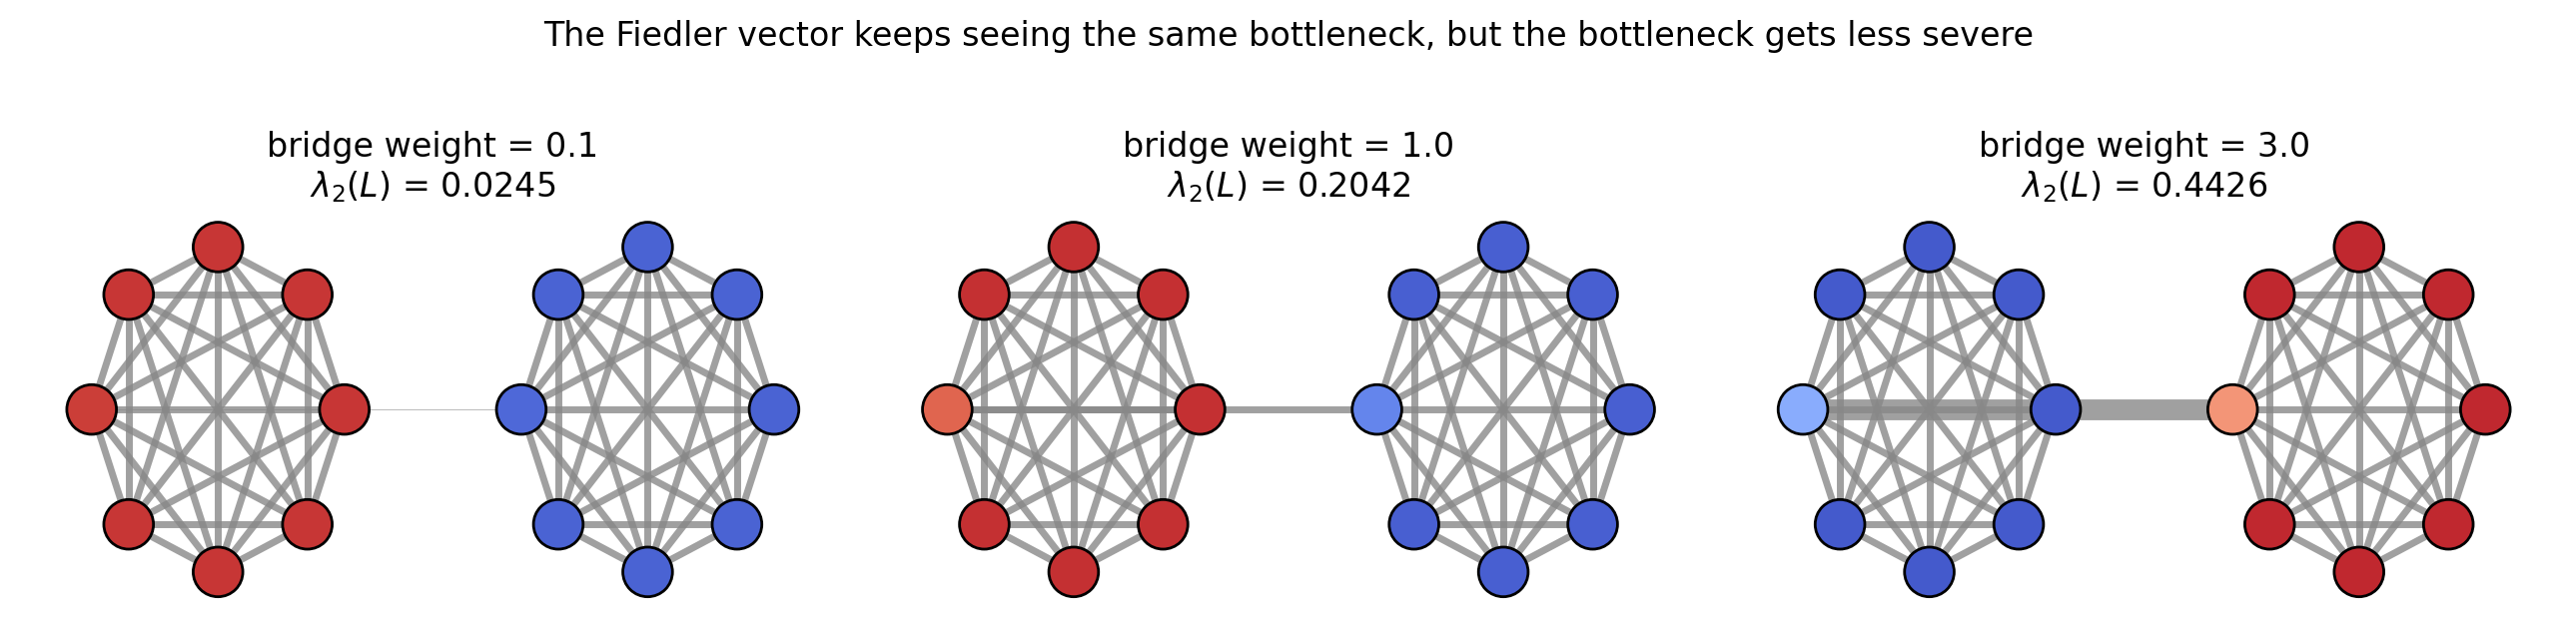

In [7]:

bridge_weights = [0.1, 1.0, 3.0]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.0), dpi=100)

for a, w in zip(ax, bridge_weights):
    G, left, right, bridge = two_cliques_with_bridge(8, 8, bridge_weight=w)
    nodes = left + right
    pos = two_clique_positions(left, right, gap=3.4, radius=1.0)

    L = nx.laplacian_matrix(G, nodelist=nodes, weight="weight").toarray()
    vals, vecs = eigh_sorted(L)
    v2 = normalize_sign(vecs[:, 1])

    node_values = {u: v2[i] for i, u in enumerate(nodes)}
    draw_graph(
        G,
        pos=pos,
        ax=a,
        node_values=node_values,
        node_labels=False,
        node_size=320,
        with_colorbar=False,
        edge_width_scale=2.5,
        vmin=-0.28,
        vmax=0.28,
    )
    a.set_title(f"bridge weight = {w:.1f}\n" + r"$\lambda_2(L)$" + f" = {vals[1]:.4f}")

fig.suptitle("The Fiedler vector keeps seeing the same bottleneck, but the bottleneck gets less severe", y=1.03)
plt.tight_layout()
plt.show()



The Fiedler vector is almost constant on each clique. It saves nearly all of its variation for the bridge. That is exactly what a "smooth but non-trivial" signal should do here.

As we strengthen the bridge, the two sides stop looking like almost-separate worlds. The graph can support variation across the cut less and less cheaply, so $\lambda_2(L)$ rises.


In [8]:

rows = []

for w in np.linspace(0.0, 3.0, 13):
    G, left, right, bridge = two_cliques_with_bridge(8, 8, bridge_weight=w)
    nodes = left + right

    L = nx.laplacian_matrix(G, nodelist=nodes, weight="weight").toarray()
    vals, _ = eigh_sorted(L)

    rows.append({
        "bridge_weight": w,
        "lambda_1": vals[0],
        "lambda_2": vals[1],
        "lambda_3": vals[2],
    })

df_bridge = pd.DataFrame(rows)
display(df_bridge.round(4))


,bridge_weight,lambda_1,lambda_2,lambda_3
0,0.00,-0.0,-0.0000,8.0
1,0.25,0.0,0.0592,8.0
2,0.50,-0.0,0.1125,8.0
3,0.75,-0.0,0.1606,8.0
4,1.00,-0.0,0.2042,8.0
5,1.25,0.0,0.2438,8.0
6,1.50,-0.0,0.2798,8.0
7,1.75,0.0,0.3129,8.0
8,2.00,0.0,0.3431,8.0
9,2.25,-0.0,0.3710,8.0


## 1.2 What if the bridge disappears?

Now set the bridge weight to zero....

Then the left clique can carry one constant signal and the right clique can carry another. The graph no longer forces those two values to agree, because there is no edge between them.

That means the nullspace gets bigger.

For a graph with $c$ connected components, the Laplacian has exactly $c$ zero eigenvalues. Component indicators live in the nullspace.


Smallest six eigenvalues:
[-0. -0.  8.  8.  8.  8.]

How many zero eigenvalues? 2
||L * 1_left|| = 0.0
||L * 1_right|| = 0.0


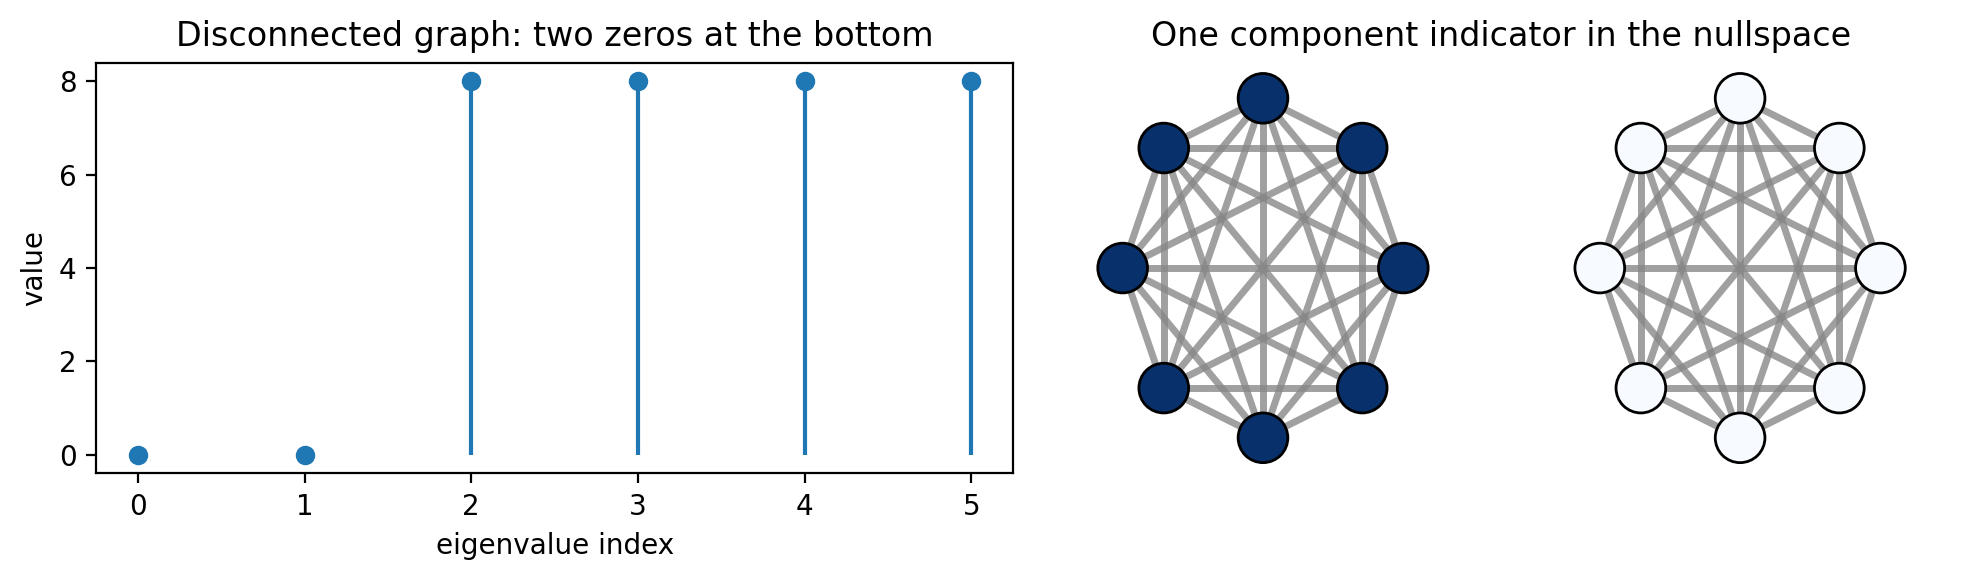

In [10]:

G_disc, left_disc, right_disc, bridge_disc = two_cliques_with_bridge(8, 8, bridge_weight=0.0)
nodes_disc = left_disc + right_disc
L_disc = nx.laplacian_matrix(G_disc, nodelist=nodes_disc, weight="weight").toarray()
vals_disc, vecs_disc = eigh_sorted(L_disc)

one_left = np.array([1.0 if u in left_disc else 0.0 for u in nodes_disc])
one_right = np.array([1.0 if u in right_disc else 0.0 for u in nodes_disc])

print("Smallest six eigenvalues:")
print(np.round(vals_disc[:6], 6))
print()
print("How many zero eigenvalues?", np.sum(np.isclose(vals_disc, 0.0, atol=1e-10)))
print("||L * 1_left|| =", np.linalg.norm(L_disc @ one_left))
print("||L * 1_right|| =", np.linalg.norm(L_disc @ one_right))

fig, ax = plt.subplots(1, 2, figsize=(10, 3), dpi=100)

ax[0].stem(range(6), vals_disc[:6], basefmt=" ")
ax[0].set_xlabel("eigenvalue index")
ax[0].set_ylabel("value")
ax[0].set_title("Disconnected graph: two zeros at the bottom")

pos_disc = two_clique_positions(left_disc, right_disc, gap=3.4, radius=1.0)
node_values_left = {u: one_left[i] for i, u in enumerate(nodes_disc)}
draw_graph(
    G_disc,
    pos=pos_disc,
    ax=ax[1],
    node_values=node_values_left,
    node_labels=False,
    cmap="Blues",
    vmin=0,
    vmax=1,
    node_size=320,
    edge_width_scale=2.5,
)
ax[1].set_title(r"One component indicator in the nullspace")

plt.tight_layout()
plt.show()


## 1.3 The optimization view: why the Fiedler vector wins

What's the Fiedler vector really solving?

For any nonzero vector $\mathbf{x}$, the **Rayleigh quotient** of the Laplacian is

$$
R_L(\mathbf{x}) = \frac{\mathbf{x}^\top L \mathbf{x}}{\mathbf{x}^\top \mathbf{x}}.
$$

Every symbol matters here.

- $\mathbf{x}$ is a signal on the nodes.
- $L$ is the Laplacian.
- The numerator $\mathbf{x}^\top L \mathbf{x}$ is roughness.
- The denominator $\mathbf{x}^\top \mathbf{x}$ is just the squared size of the signal.

So $R_L(\mathbf{x})$ means: **roughness per unit signal energy**.

Now block the trivial constant direction by requiring $\mathbf{x}^\top \mathbf{1} = 0$. Then

$$
\lambda_2(L) = \min_{\mathbf{x} \ne \mathbf{0},\ \mathbf{x}^\top \mathbf{1} = 0} R_L(\mathbf{x}).
$$

That sentence is worth keeping.

The Fiedler vector is the smoothest unit-size signal that is not allowed to be constant.


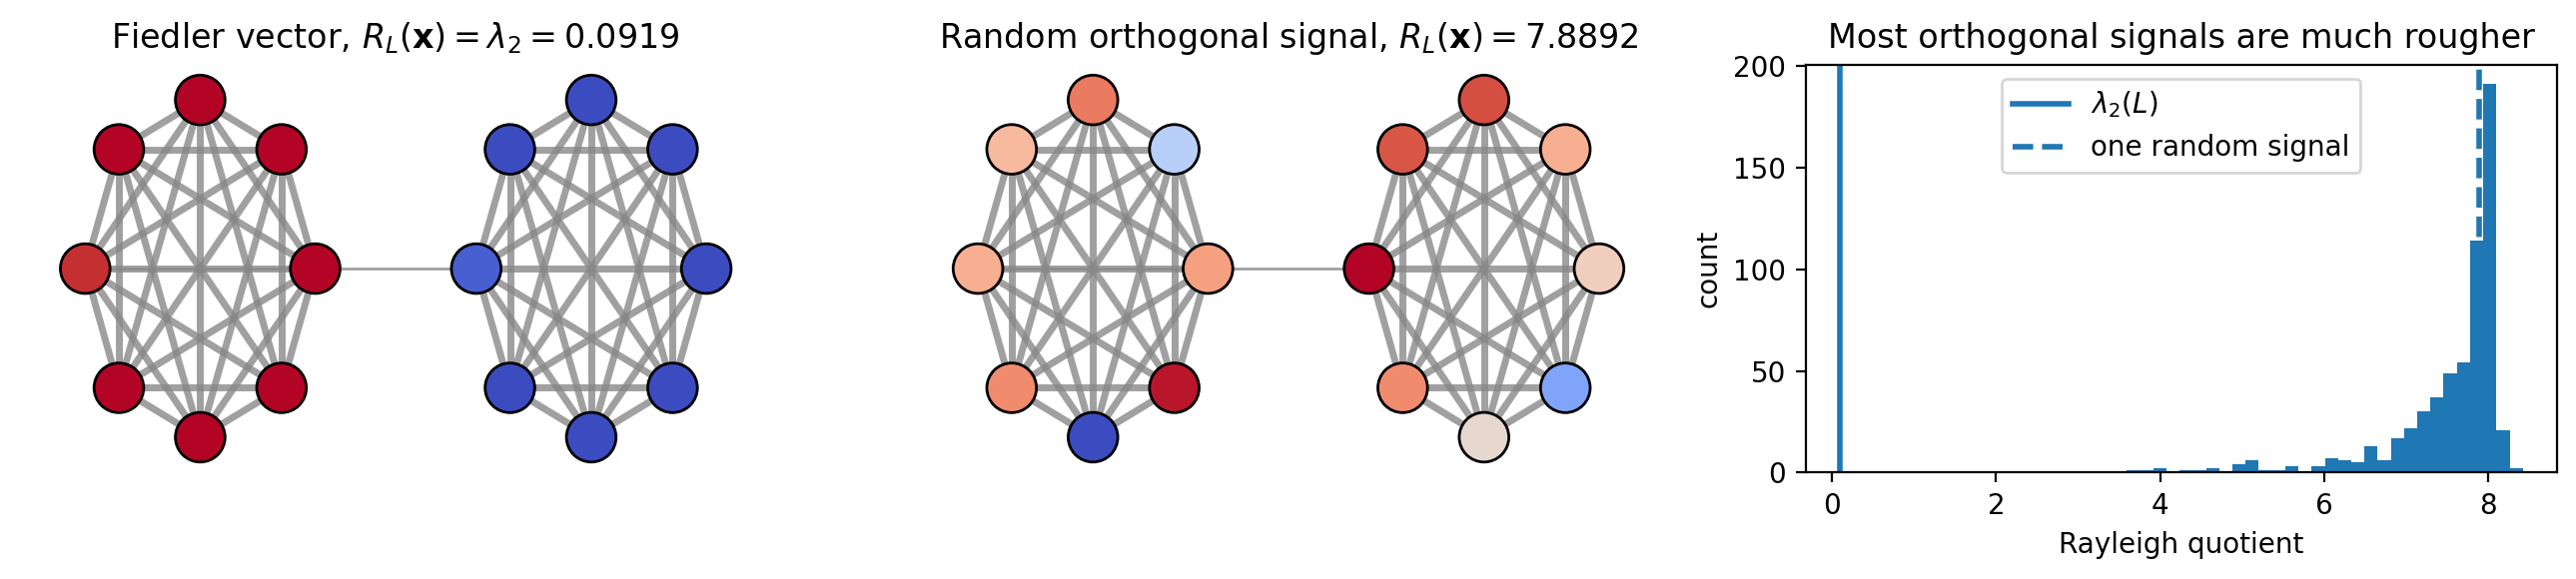

In [12]:

G_rq, left_rq, right_rq, bridge_rq = two_cliques_with_bridge(8, 8, bridge_weight=0.4)
nodes_rq = left_rq + right_rq
pos_rq = two_clique_positions(left_rq, right_rq, gap=3.4, radius=1.0)

L_rq = nx.laplacian_matrix(G_rq, nodelist=nodes_rq, weight="weight").toarray()
vals_rq, vecs_rq = eigh_sorted(L_rq)
v2_rq = normalize_sign(vecs_rq[:, 1])

x_rand = rng.normal(size=len(nodes_rq))
x_rand = x_rand - x_rand.mean()
x_rand = x_rand / np.linalg.norm(x_rand)

rq_rand = x_rand @ L_rq @ x_rand

samples = []
for _ in range(600):
    x = rng.normal(size=len(nodes_rq))
    x = x - x.mean()
    x = x / np.linalg.norm(x)
    samples.append(x @ L_rq @ x)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.0), dpi=100)

draw_graph(
    G_rq,
    pos=pos_rq,
    ax=ax[0],
    node_values={u: v2_rq[i] for i, u in enumerate(nodes_rq)},
    node_labels=False,
    node_size=320,
    edge_width_scale=2.5,
)
ax[0].set_title(r"Fiedler vector, $R_L(\mathbf{x}) = \lambda_2 = $" + f"{vals_rq[1]:.4f}")

draw_graph(
    G_rq,
    pos=pos_rq,
    ax=ax[1],
    node_values={u: x_rand[i] for i, u in enumerate(nodes_rq)},
    node_labels=False,
    node_size=320,
    edge_width_scale=2.5,
)
ax[1].set_title(r"Random orthogonal signal, $R_L(\mathbf{x}) = $" + f"{rq_rand:.4f}")

ax[2].hist(samples, bins=30)
ax[2].axvline(vals_rq[1], linewidth=2, label=r"$\lambda_2(L)$")
ax[2].axvline(rq_rand, linewidth=2, linestyle="--", label="one random signal")
ax[2].set_xlabel("Rayleigh quotient")
ax[2].set_ylabel("count")
ax[2].set_title("Most orthogonal signals are much rougher")
ax[2].legend()

plt.tight_layout()
plt.show()


Random orthogonal signals waste variation all over the graph. The Fiedler vector does not. It spends almost all of its disagreement where the graph is weakest.

## 1.4 From a soft signal to a hard cut

A vector is nice. A partition is nicer.

Eventually we want to say: these nodes belong together.

For a set of nodes $S \subseteq V$, the **conductance** is

$$
\phi(S) =
\frac{\text{weight of edges leaving } S}
{\min(\mathrm{vol}(S), \mathrm{vol}(V \setminus S))}.
$$

Here $\mathrm{vol}(S)$ means the sum of degrees inside $S$. So a low-conductance cut has two properties at once:

- not many edges cross it, and
- neither side is tiny.

Now the spectral trick.

The Fiedler vector gives a score to every node. Sort nodes by that score, sweep a threshold from left to right, and evaluate the cut at every threshold. That is a **sweep cut**.

For cut problems, the normalized Laplacian is the natural matrix. Its second eigenvalue can be written through a normalized Rayleigh quotient, and Cheeger-style inequalities say:

- small $\lambda_2(L_{\text{sym}})$ means some low-conductance bottleneck exists,
- the second eigenvector gives a soft version of that bottleneck,
- a sweep over that vector usually finds a good actual cut.


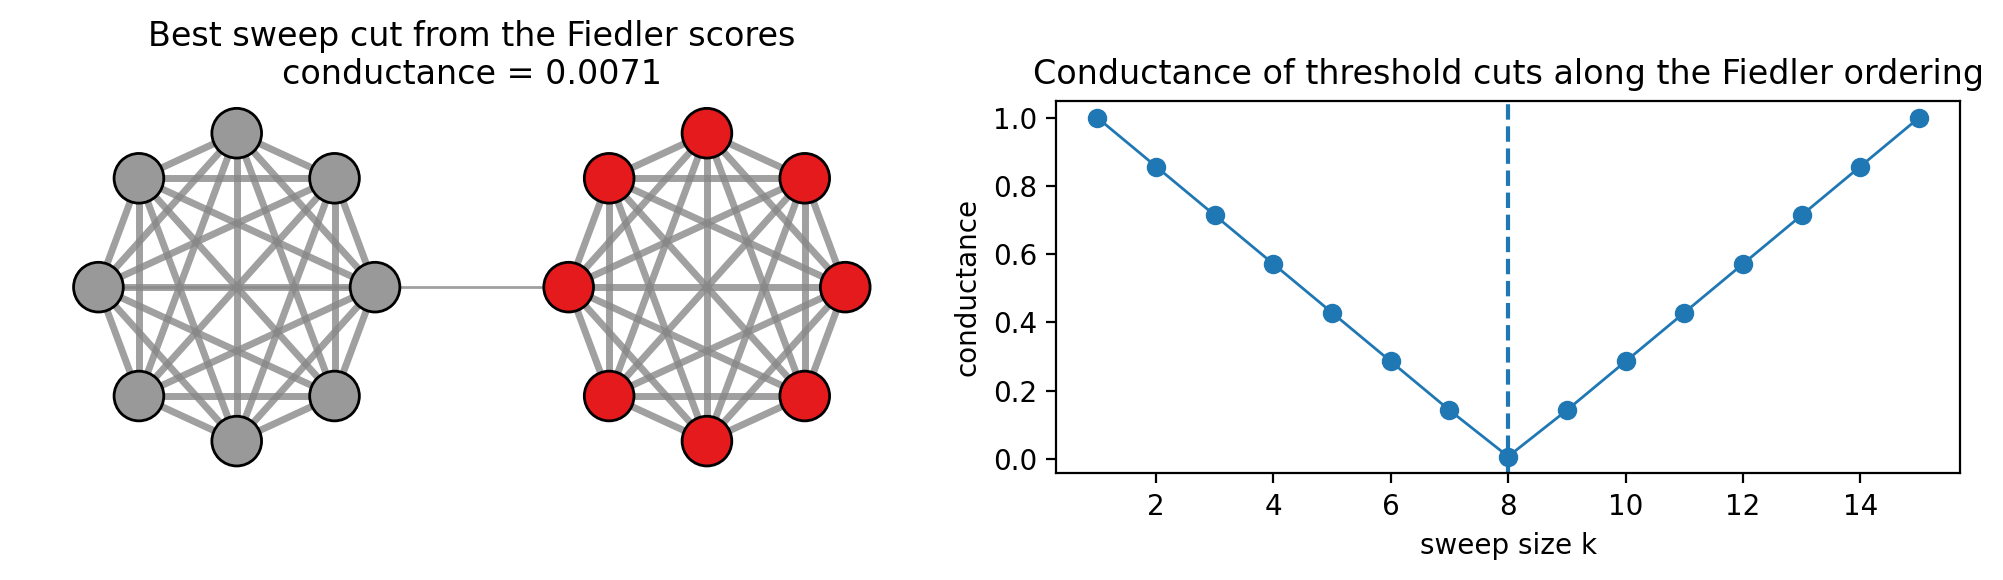

Best set found by the sweep cut:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [15]:

G_cut, left_cut, right_cut, bridge_cut = two_cliques_with_bridge(8, 8, bridge_weight=0.4)
nodes_cut = left_cut + right_cut
pos_cut = two_clique_positions(left_cut, right_cut, gap=3.4, radius=1.0)

A_cut, _ = adjacency_sparse(G_cut, nodelist=nodes_cut, weight="weight")
Lsym_cut = normalized_laplacian_sym(A_cut).toarray()
vals_cut, vecs_cut = eigh_sorted(Lsym_cut)
v2_cut = normalize_sign(vecs_cut[:, 1])

best_phi, best_S, phis, order, sets = fiedler_sweep_cut(G_cut, v2_cut, nodes_cut, weight="weight")
cut_labels = {u: (1 if u in best_S else 0) for u in nodes_cut}

fig, ax = plt.subplots(1, 2, figsize=(10, 3.0), dpi=100)

draw_graph(
    G_cut,
    pos=pos_cut,
    ax=ax[0],
    node_values=cut_labels,
    node_labels=False,
    cmap="Set1",
    vmin=0,
    vmax=1,
    node_size=320,
    edge_width_scale=2.5,
)
ax[0].set_title(f"Best sweep cut from the Fiedler scores\nconductance = {best_phi:.4f}")

ax[1].plot(range(1, len(nodes_cut)), phis, marker="o", linewidth=1)
ax[1].axvline(len(best_S), linestyle="--", linewidth=1.5)
ax[1].set_xlabel("sweep size k")
ax[1].set_ylabel("conductance")
ax[1].set_title("Conductance of threshold cuts along the Fiedler ordering")

plt.tight_layout()
plt.show()

print("Best set found by the sweep cut:")
print(sorted(best_S))


On this graph, the best threshold lands exactly where you would hope: one clique on the left, one on the right.

That is Cheeger intuition in action. The eigenvector is soft. The sweep makes it discrete.


## 1.5 One edge, many stories

Let's now turn the bridge weight up slowly and watch three quantities:

- $\lambda_2(L)$, the algebraic connectivity,
- the best conductance found by a Fiedler sweep on $L_{\text{sym}}$,
- the lazy-walk spectral gap $\gamma = 1 - \mu_2(P_{\text{lazy}})$.

If all three move together, that is not an accident. They are different lenses on the same bottleneck story.


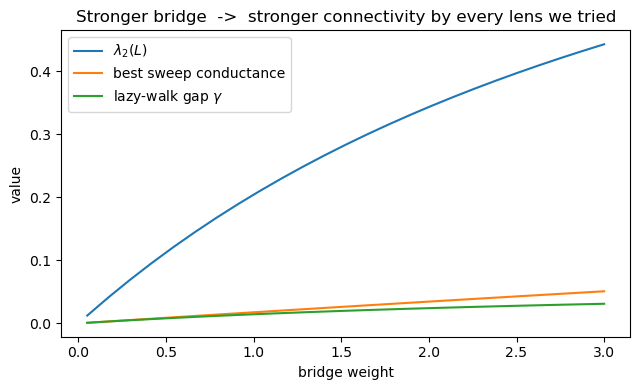

In [17]:

bridge_grid = np.linspace(0.05, 3.0, 25)

lam2_values = []
phi_values = []
gap_values = []

for w in bridge_grid:
    G_w, left_w, right_w, bridge_w = two_cliques_with_bridge(8, 8, bridge_weight=w)
    nodes_w = left_w + right_w

    L_w = nx.laplacian_matrix(G_w, nodelist=nodes_w, weight="weight").toarray()
    vals_w, _ = eigh_sorted(L_w)
    lam2_values.append(vals_w[1])

    A_w, _ = adjacency_sparse(G_w, nodelist=nodes_w, weight="weight")
    Lsym_w = normalized_laplacian_sym(A_w).toarray()
    vals_sym_w, vecs_sym_w = eigh_sorted(Lsym_w)
    v2_sym_w = normalize_sign(vecs_sym_w[:, 1])
    phi_w, _, _, _, _ = fiedler_sweep_cut(G_w, v2_sym_w, nodes_w, weight="weight")
    phi_values.append(phi_w)

    P_lazy_w = make_lazy(random_walk_matrix(A_w), beta=0.5).toarray()
    evals_w = np.sort(np.linalg.eigvals(P_lazy_w).real)[::-1]
    gap_values.append(1.0 - evals_w[1])

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4), dpi=100)
ax.plot(bridge_grid, lam2_values, label=r"$\lambda_2(L)$")
ax.plot(bridge_grid, phi_values, label="best sweep conductance")
ax.plot(bridge_grid, gap_values, label=r"lazy-walk gap $\gamma$")
ax.set_xlabel("bridge weight")
ax.set_ylabel("value")
ax.set_title("Stronger bridge  ->  stronger connectivity by every lens we tried")
ax.legend()
plt.tight_layout()
plt.show()


## Your turn!

1. Replace the two equal cliques with cliques of sizes 6 and 10. What changes in the Fiedler vector? What stays the same?
2. Add a **second** bridge edge instead of increasing the weight of one bridge. Does $\lambda_2$ rise faster or slower than you expected?
3. On the same graph, compare sweep cuts from the raw Laplacian eigenvector and the normalized Laplacian eigenvector. When do they differ?


# Part 2 — The Spectral Gap


## 2.1 Which gap do we mean?

The phrase **spectral gap** is overloaded. So let's pin it down.

For a Laplacian, the gap usually means the second-smallest eigenvalue:

$$
\lambda_2(L)
\quad \text{or} \quad
\nu_2 = \lambda_2(L_{\text{sym}}).
$$

For a random-walk matrix $P = D^{-1}A$, the top eigenvalue is $1$. The relevant gap is the distance from $1$ to the next eigenvalue that controls convergence.

On a **lazy random walk**,

$$
P_{\text{lazy}} = \tfrac12(I + P),
$$

all eigenvalues land in $[0, 1]$, so the gap is simply

$$
\gamma = 1 - \mu_2(P_{\text{lazy}}).
$$

Why laziness? Because plain random walks on bipartite graphs can oscillate forever. Laziness kills that parity flip. Just like in real life lol

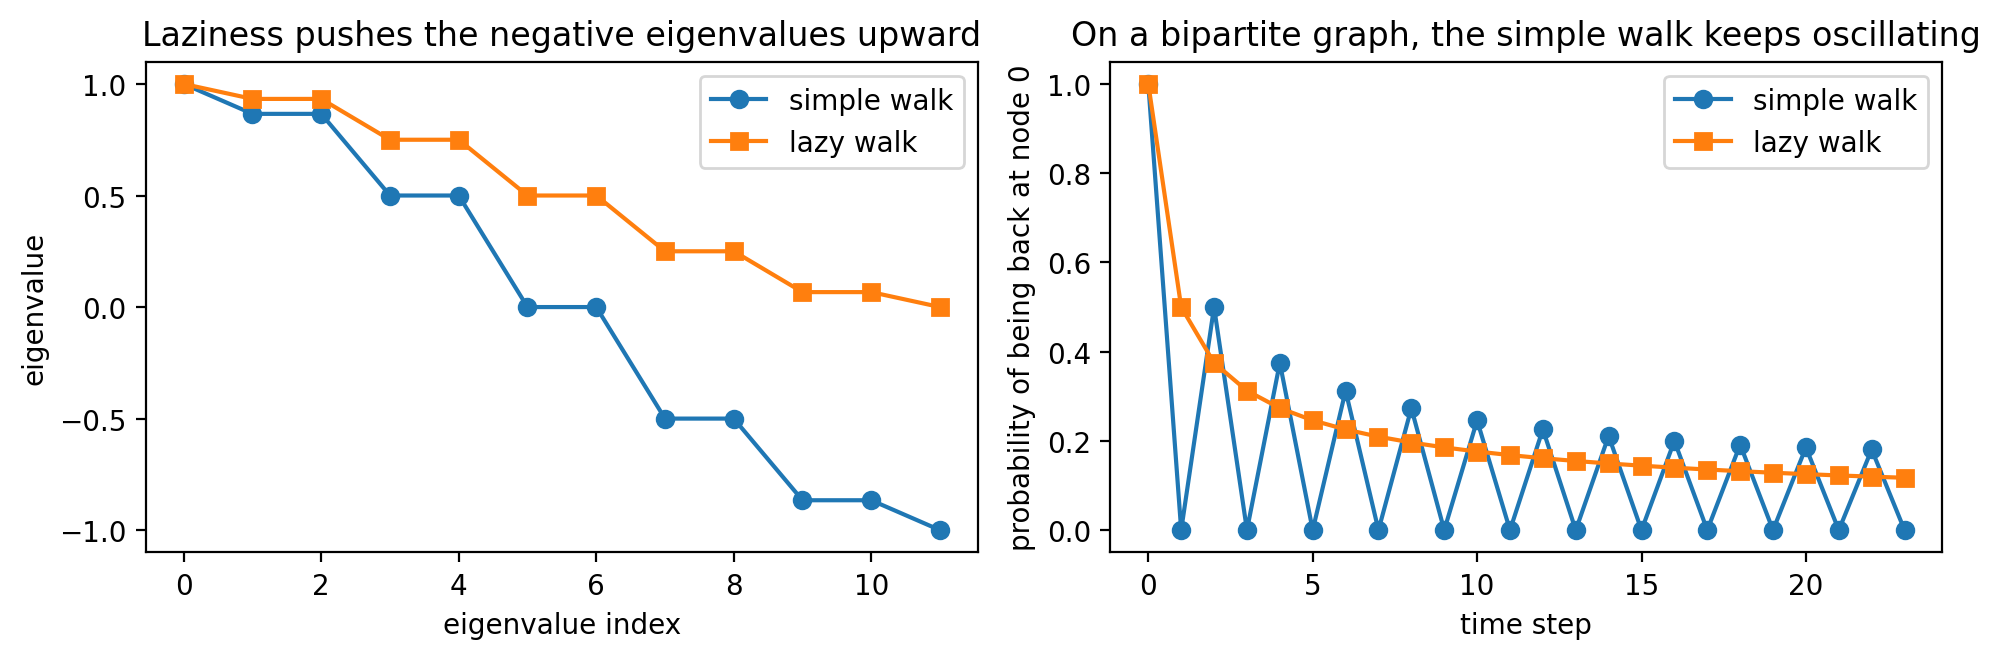

In [18]:

G_cycle = nx.cycle_graph(12)
A_cycle, nodes_cycle = adjacency_sparse(G_cycle)
P_cycle = random_walk_matrix(A_cycle).toarray()
P_lazy_cycle = make_lazy(sp.csr_matrix(P_cycle), beta=0.5).toarray()

evals_cycle = np.sort(np.linalg.eigvals(P_cycle).real)[::-1]
evals_lazy_cycle = np.sort(np.linalg.eigvals(P_lazy_cycle).real)[::-1]

p = np.zeros(len(nodes_cycle))
p[0] = 1.0
mass_at_zero = []
mass_at_zero_lazy = []

p_lazy = p.copy()
for _ in range(24):
    mass_at_zero.append(p[0])
    mass_at_zero_lazy.append(p_lazy[0])
    p = p @ P_cycle
    p_lazy = p_lazy @ P_lazy_cycle

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), dpi=100)

ax[0].plot(evals_cycle, marker="o", label="simple walk")
ax[0].plot(evals_lazy_cycle, marker="s", label="lazy walk")
ax[0].set_xlabel("eigenvalue index")
ax[0].set_ylabel("eigenvalue")
ax[0].set_title("Laziness pushes the negative eigenvalues upward")
ax[0].legend()

ax[1].plot(mass_at_zero, marker="o", label="simple walk")
ax[1].plot(mass_at_zero_lazy, marker="s", label="lazy walk")
ax[1].set_xlabel("time step")
ax[1].set_ylabel("probability of being back at node 0")
ax[1].set_title("On a bipartite graph, the simple walk keeps oscillating")
ax[1].legend()

plt.tight_layout()
plt.show()


The simple walk remembers parity: even steps and odd steps behave differently forever. The lazy walk leaks that memory away.

That is why, in practice, people often talk about the spectral gap of the **lazy** walk or the **absolute** gap of the non-lazy walk. It keeps the convergence story clean.


## 2.2 Bigger gap, faster forgetting

Write an initial distribution as a sum of eigenmodes of the lazy walk matrix. The stationary mode has eigenvalue $1$. Every other mode gets multiplied by $\mu_k^t$ after $t$ steps.

So if $\mu_2$ is close to $1$, the slowest non-stationary mode hangs around. Mixing is slow.

If $\mu_2$ is much smaller than $1$, that slow mode dies quickly. Mixing is fast.

This is why the spectral gap acts like a rough **connectivity certificate**: a graph with a healthy gap has no cheap bottleneck for probability mass to get stuck behind.


,graph,nu2 = lambda2(L_sym),mu2(P_lazy),gamma,nu2 / 2
0,barbell,0.0069,0.9965,0.0035,0.0035
1,4-regular,0.2741,0.8630,0.1370,0.1370


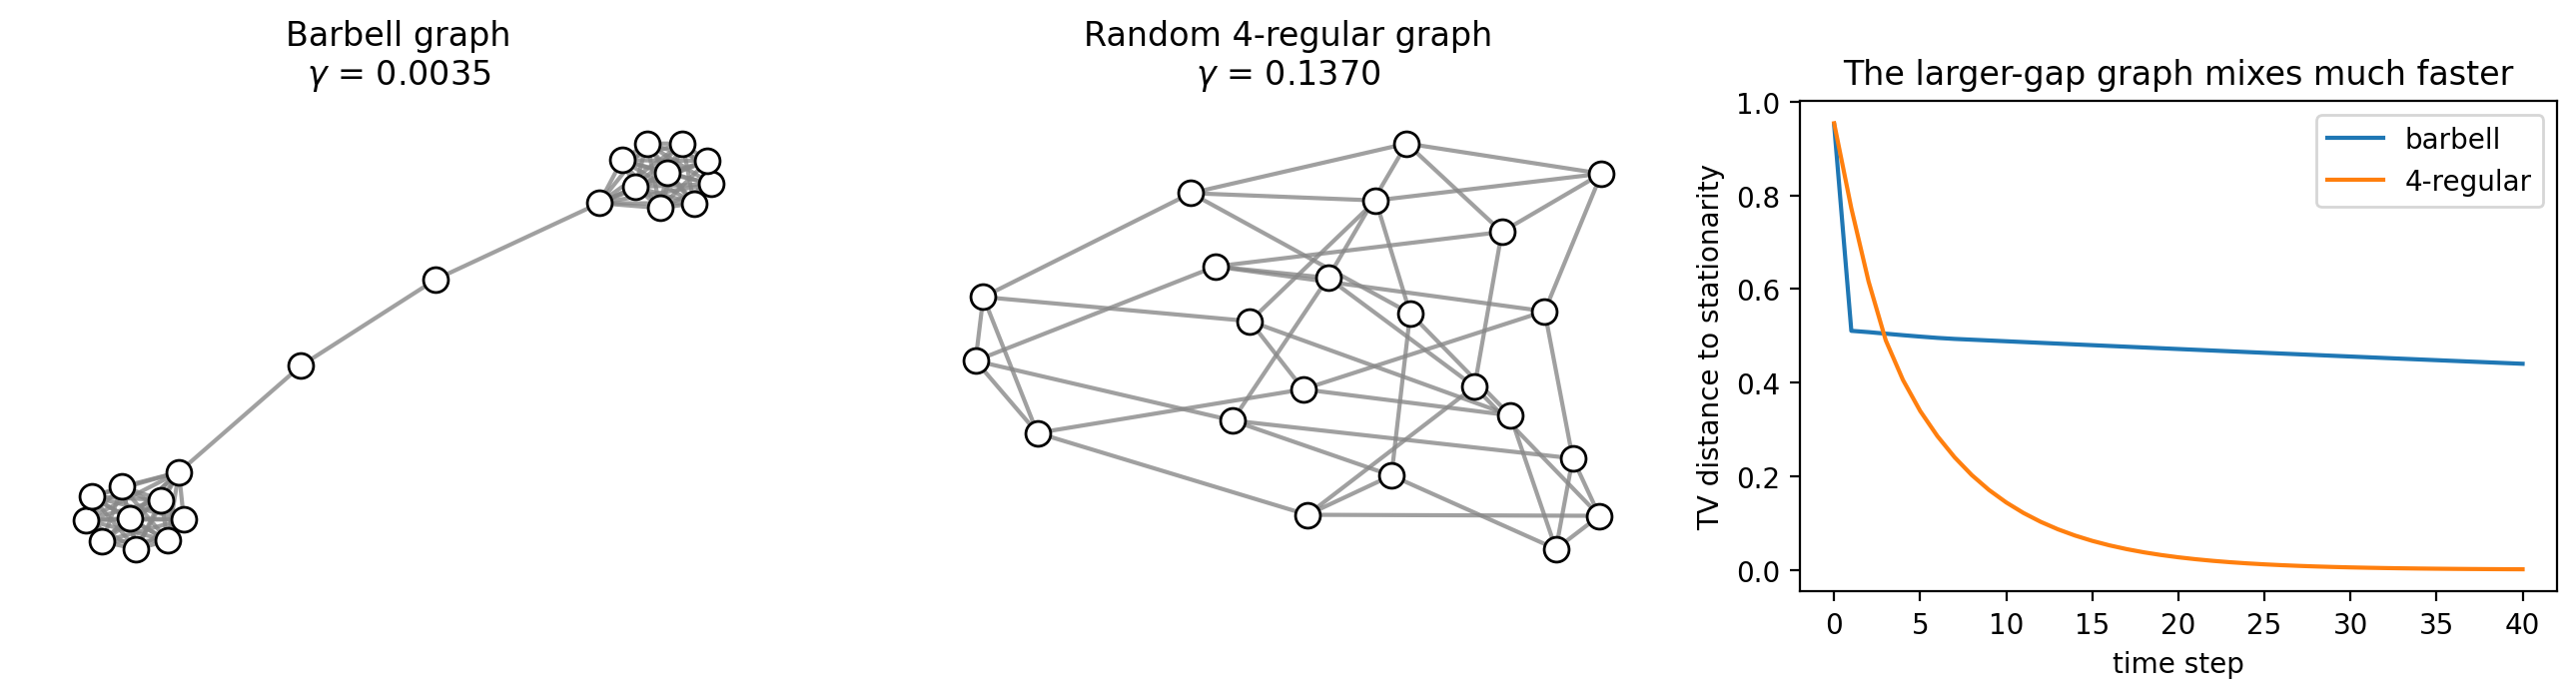

In [19]:

G_barbell = nx.barbell_graph(10, 2)
G_regular = nx.random_regular_graph(4, G_barbell.number_of_nodes(), seed=5052)

def lazy_gap_summary(G):
    A, nodes = adjacency_sparse(G)
    Lsym = normalized_laplacian_sym(A).toarray()
    vals_lsym, _ = eigh_sorted(Lsym)
    nu2 = vals_lsym[1]

    P_lazy = make_lazy(random_walk_matrix(A), beta=0.5).toarray()
    evals = np.sort(np.linalg.eigvals(P_lazy).real)[::-1]
    mu2 = evals[1]
    gamma = 1.0 - mu2
    return nu2, mu2, gamma

nu2_bar, mu2_bar, gap_bar = lazy_gap_summary(G_barbell)
nu2_reg, mu2_reg, gap_reg = lazy_gap_summary(G_regular)

tv_bar, pi_bar, nodes_bar = random_walk_tv_distances(G_barbell, start=0, T=40, lazy=True)
tv_reg, pi_reg, nodes_reg = random_walk_tv_distances(G_regular, start=0, T=40, lazy=True)

summary_gap = pd.DataFrame([
    {"graph": "barbell", "nu2 = lambda2(L_sym)": nu2_bar, "mu2(P_lazy)": mu2_bar, "gamma": gap_bar, "nu2 / 2": nu2_bar / 2},
    {"graph": "4-regular", "nu2 = lambda2(L_sym)": nu2_reg, "mu2(P_lazy)": mu2_reg, "gamma": gap_reg, "nu2 / 2": nu2_reg / 2},
])
display(summary_gap.round(4))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), dpi=100)

draw_graph(G_barbell, pos=nx.spring_layout(G_barbell, seed=5052), ax=ax[0], node_labels=False, node_size=80)
ax[0].set_title(f"Barbell graph\n" + r"$\gamma$" + f" = {gap_bar:.4f}")

draw_graph(G_regular, pos=nx.spring_layout(G_regular, seed=5052), ax=ax[1], node_labels=False, node_size=80)
ax[1].set_title(f"Random 4-regular graph\n" + r"$\gamma$" + f" = {gap_reg:.4f}")

ax[2].plot(tv_bar, label="barbell")
ax[2].plot(tv_reg, label="4-regular")
ax[2].set_xlabel("time step")
ax[2].set_ylabel("TV distance to stationarity")
ax[2].set_title("The larger-gap graph mixes much faster")
ax[2].legend()

plt.tight_layout()
plt.show()


A nice little identity shows up in the table above.

For an undirected graph, the lazy random walk and the normalized Laplacian carry the same eigenvalue information:

$$
P_{\text{lazy}} \sim I - \tfrac12 L_{\text{sym}}.
$$

So their eigenvalues satisfy

$$
\mu_k(P_{\text{lazy}}) = 1 - \tfrac12 \nu_k,
$$

where $\nu_k$ is an eigenvalue of $L_{\text{sym}}$.

That is why the last two columns line up. Same story. Different matrix.


## 2.3 The gap as a practical certificate

A zero gap means disconnection. A tiny gap means near-disconnection. A healthy gap means no single bottleneck dominates the dynamics.

It is not a full fingerprint of the graph. Many non-isomorphic graphs can have similar gaps.

But as a one-number answer to the question *"will diffusion and random walks get stuck?"*, it is hard to beat.


## Your turn!

1. Replace the barbell graph with a path graph of the same size. How does the lazy-walk gap compare?
2. Add one extra bridge edge to the barbell. How much does the mixing curve change?
3. Try a non-lazy walk and plot the **absolute** spectral gap $1 - \max_{k \ge 2} |\mu_k|$. When does that become the right definition?


# Part 3 — Diffusion, Random Walks, and Disease Spreading


## 3.1 Diffusion is just the Laplacian acting in time

If $\mathbf{x}(t)$ is a time-dependent signal on the nodes, the continuous-time diffusion equation is

$$
\frac{d\mathbf{x}}{dt} = -L\mathbf{x}.
$$

Every symbol matters.

- $\mathbf{x}(t)$ is the vector of node values at time $t$.
- $L$ is the graph Laplacian.
- The minus sign means differences get smoothed out.

The exact solution is

$$
\mathbf{x}(t) = e^{-tL}\mathbf{x}(0).
$$

That matrix exponential looks weird but The idea is simple: every eigenmode decays at its own rate. This is the graph heat equation. Same math as a physical diffusion process, just living on a network instead of a line or a sheet of metal.


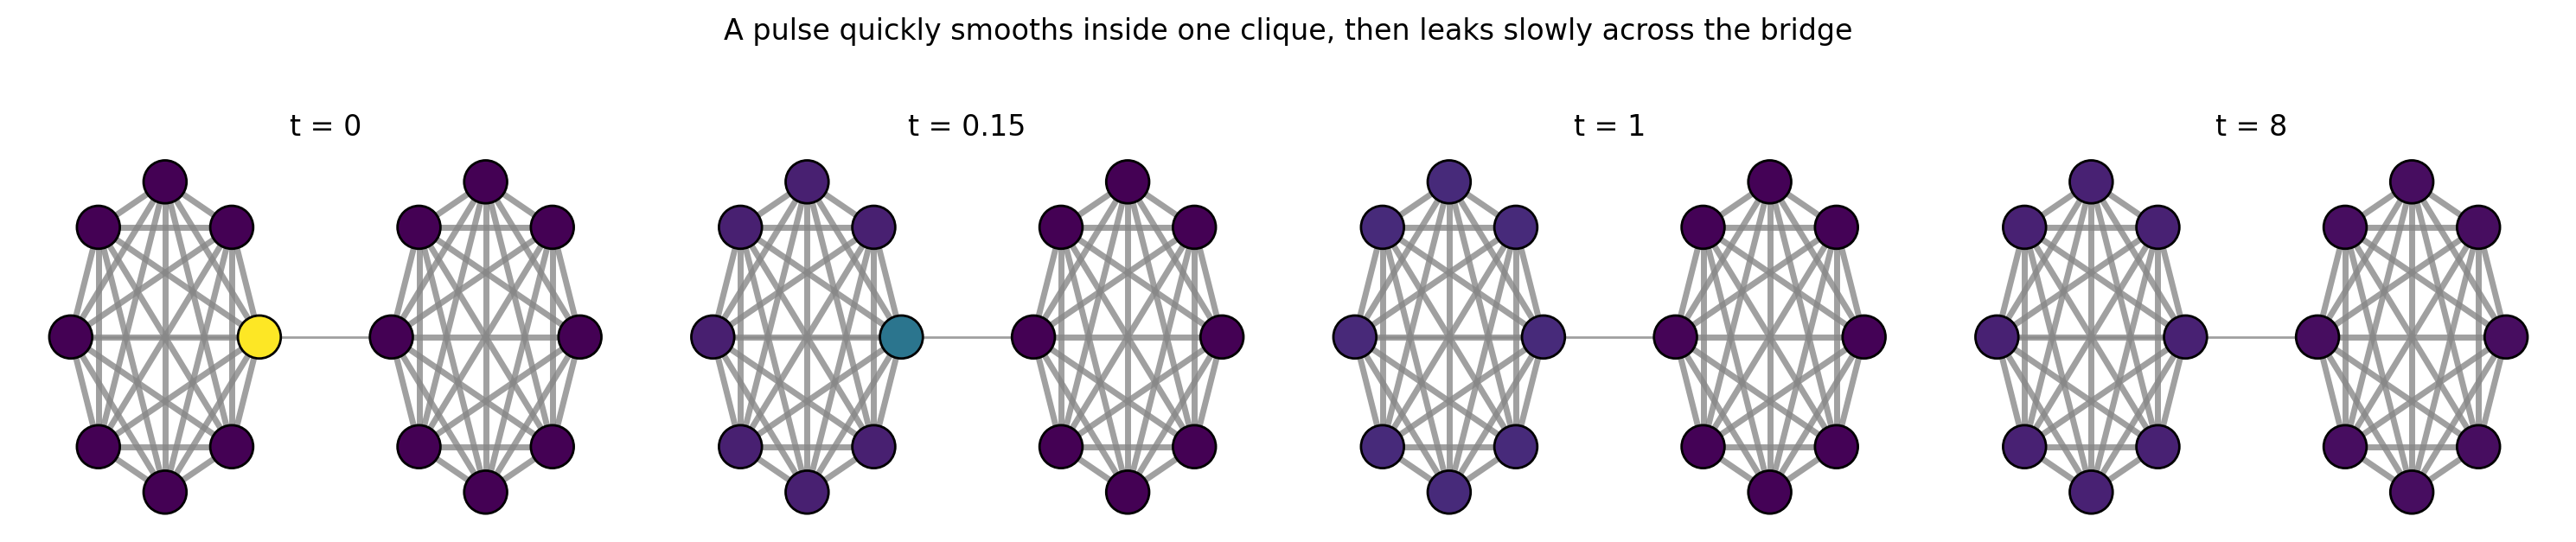

In [20]:

G_diff, left_diff, right_diff, bridge_diff = two_cliques_with_bridge(8, 8, bridge_weight=0.4)
nodes_diff = left_diff + right_diff
pos_diff = two_clique_positions(left_diff, right_diff, gap=3.4, radius=1.0)

L_diff = nx.laplacian_matrix(G_diff, nodelist=nodes_diff, weight="weight").toarray()

x0_diff = np.zeros(len(nodes_diff))
x0_diff[0] = 1.0

times_diff = [0.0, 0.15, 1.0, 8.0]

fig, ax = plt.subplots(1, 4, figsize=(15, 3.0), dpi=100)

for a, t in zip(ax, times_diff):
    xt = diffusion_exact(L_diff, x0_diff, t)
    draw_graph(
        G_diff,
        pos=pos_diff,
        ax=a,
        node_values={u: xt[i] for i, u in enumerate(nodes_diff)},
        node_labels=False,
        cmap="viridis",
        vmin=0.0,
        vmax=x0_diff.max(),
        node_size=320,
        edge_width_scale=2.5,
    )
    a.set_title(f"t = {t:g}")

fig.suptitle("A pulse quickly smooths inside one clique, then leaks slowly across the bridge", y=1.03)
plt.tight_layout()
plt.show()


Inside each clique, diffusion is fast because there are many edges. Crossing the bridge is slower because there is only one cheap path connecting the two halves.

So diffusion always tells you two things at once:

- what the local geometry is doing,
- and where the global bottlenecks are.


## 3.2 Every mode has its own clock

If $Lv_k = \lambda_k v_k$ and the initial signal can be expanded as

$$
\mathbf{x}(0) = \sum_{k=1}^n c_k v_k,
$$

then diffusion gives

$$
\mathbf{x}(t) = \sum_{k=1}^n c_k e^{-t\lambda_k} v_k.
$$

That formula is worth staring at.

- $c_k$ tells you how much mode $k$ is present at time zero.
- $e^{-t\lambda_k}$ tells you how fast that mode dies.

So:

- large eigenvalue $\lambda_k$  $\rightarrow$  fast decay,
- small eigenvalue $\lambda_k$  $\rightarrow$  slow decay.

That is why slow global dynamics live in the small Laplacian eigenvalues. Bottlenecks show up as stubborn modes.


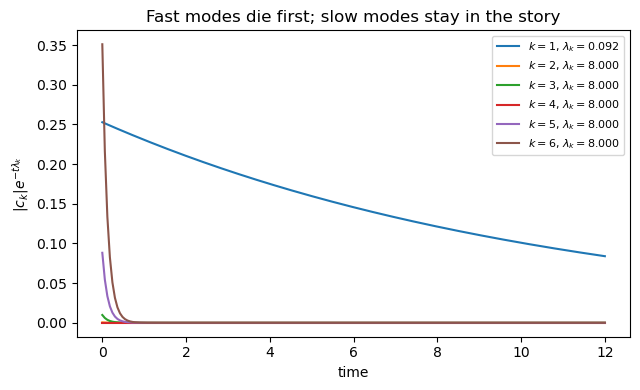

In [23]:

vals_diff, vecs_diff = eigh_sorted(L_diff)
coeffs_diff = vecs_diff.T @ x0_diff

times_modal = np.linspace(0, 12, 200)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4), dpi=100)
for k in range(1, 7):
    mode_strength = np.abs(coeffs_diff[k]) * np.exp(-vals_diff[k] * times_modal)
    ax.plot(times_modal, mode_strength, label=rf"$k={k}$, $\lambda_k={vals_diff[k]:.3f}$")

ax.set_xlabel("time")
ax.set_ylabel(r"$|c_k| e^{-t\lambda_k}$")
ax.set_title("Fast modes die first; slow modes stay in the story")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3.3 Consensus is diffusion with a different story

Suppose each node stores an opinion, a temperature, or an estimate. If every node repeatedly moves toward its neighbors, the same equation appears:

$$
\frac{d\mathbf{x}}{dt} = -L\mathbf{x}.
$$

The final state is everyone agreeing on the average value.

The rate of agreement is controlled by $\lambda_2(L)$. Bigger $\lambda_2$ means faster collapse to consensus.


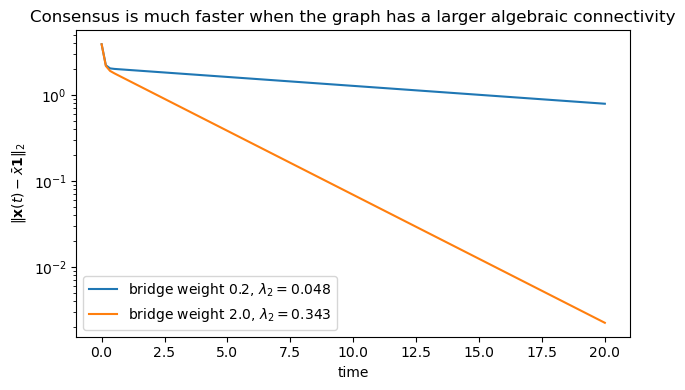

In [24]:

times_cons = np.linspace(0, 20, 120)
x0_cons = rng.normal(size=16)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4), dpi=100)

for w in [0.2, 2.0]:
    G_cons, left_cons, right_cons, bridge_cons = two_cliques_with_bridge(8, 8, bridge_weight=w)
    nodes_cons = left_cons + right_cons
    L_cons = nx.laplacian_matrix(G_cons, nodelist=nodes_cons, weight="weight").toarray()
    vals_cons, _ = eigh_sorted(L_cons)

    xbar = x0_cons.mean()
    errs = []
    for t in times_cons:
        xt = diffusion_exact(L_cons, x0_cons, t)
        errs.append(np.linalg.norm(xt - xbar))

    ax.semilogy(times_cons, errs, label=rf"bridge weight {w:.1f}, $\lambda_2={vals_cons[1]:.3f}$")

ax.set_xlabel("time")
ax.set_ylabel(r"$\|\mathbf{x}(t) - \bar{x}\mathbf{1}\|_2$")
ax.set_title("Consensus is much faster when the graph has a larger algebraic connectivity")
ax.legend()
plt.tight_layout()
plt.show()


## 3.4 When spreading has a threshold

Diffusion smooths a conserved quantity. Epidemics do not. Infection can grow.

A standard early-stage approximation of SIS dynamics is

$$
\frac{d\mathbf{x}}{dt} = (\beta A - \delta I)\mathbf{x}.
$$

Here:

- $\mathbf{x}(t)$ is a vector of infection probabilities or expected infection levels,
- $\beta$ is the infection rate along edges,
- $\delta$ is the recovery rate,
- $A$ is the adjacency matrix.

Now the dominant mode is an **adjacency** eigenvector, not a Laplacian one. Growth happens when the top exponent is positive:

$$
\beta \lambda_1(A) - \delta > 0.
$$

So the mean-field epidemic threshold is

$$
\frac{\beta}{\delta} \approx \frac{1}{\lambda_1(A)}.
$$

Large adjacency spectral radius means the network needs less transmission strength to sustain spread.


,graph,edges,lambda_1(A),1 / lambda_1(A)
0,4-regular,80,4.0000,0.2500
1,hub-heavy,80,5.7351,0.1744


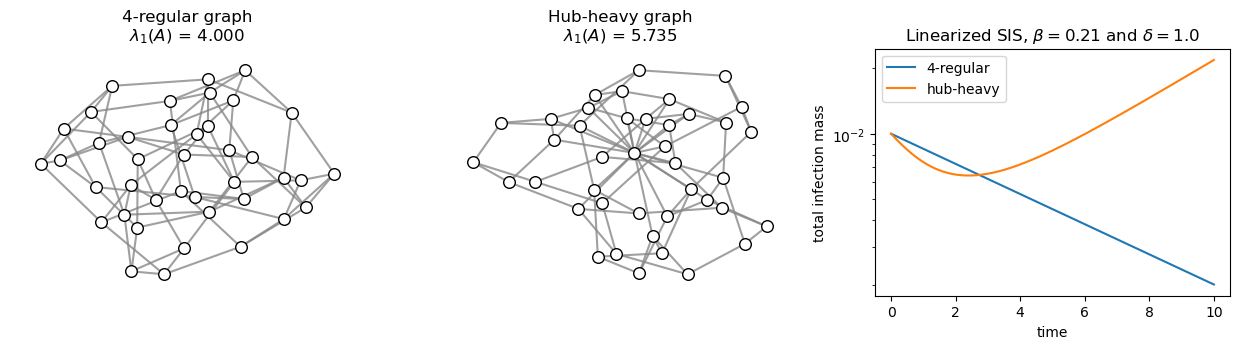

In [25]:

G_bal = nx.random_regular_graph(4, 40, seed=5052)
G_hub, hub_node = structured_hub_graph(n=40, seed=5052)

def adjacency_spectral_radius(G):
    A, _ = adjacency_sparse(G)
    return float(spla.eigsh(A, k=1, which="LA", return_eigenvectors=False)[0])

lam1_bal = adjacency_spectral_radius(G_bal)
lam1_hub = adjacency_spectral_radius(G_hub)

beta = 0.21
delta = 1.0
times_epi = np.linspace(0, 10, 200)

def linear_sis_mass(G, beta, delta, times):
    A, nodes = adjacency_sparse(G)
    M = beta * A.toarray() - delta * np.eye(A.shape[0])
    x0 = np.zeros(A.shape[0])
    x0[0] = 0.01

    masses = []
    for t in times:
        xt = la.expm(t * M) @ x0
        masses.append(xt.sum())
    return np.array(masses)

mass_bal = linear_sis_mass(G_bal, beta, delta, times_epi)
mass_hub = linear_sis_mass(G_hub, beta, delta, times_epi)

threshold_table = pd.DataFrame([
    {"graph": "4-regular", "edges": G_bal.number_of_edges(), "lambda_1(A)": lam1_bal, "1 / lambda_1(A)": 1 / lam1_bal},
    {"graph": "hub-heavy", "edges": G_hub.number_of_edges(), "lambda_1(A)": lam1_hub, "1 / lambda_1(A)": 1 / lam1_hub},
])
display(threshold_table.round(4))

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.6), dpi=100)

draw_graph(G_bal, pos=nx.spring_layout(G_bal, seed=5052), ax=ax[0], node_labels=False, node_size=70)
ax[0].set_title(f"4-regular graph\n" + r"$\lambda_1(A)$" + f" = {lam1_bal:.3f}")

draw_graph(G_hub, pos=nx.spring_layout(G_hub, seed=5052), ax=ax[1], node_labels=False, node_size=70)
ax[1].set_title(f"Hub-heavy graph\n" + r"$\lambda_1(A)$" + f" = {lam1_hub:.3f}")

ax[2].semilogy(times_epi, mass_bal, label="4-regular")
ax[2].semilogy(times_epi, mass_hub, label="hub-heavy")
ax[2].set_xlabel("time")
ax[2].set_ylabel("total infection mass")
ax[2].set_title(rf"Linearized SIS, $\beta={beta:.2f}$ and $\delta={delta:.1f}$")
ax[2].legend()

plt.tight_layout()
plt.show()


The two graphs above have the same number of edges. But the hub-heavy graph has a much larger adjacency spectral radius, so the same infection rate pushes it above threshold much more easily.

That is a clean example of a general rule:

- **Laplacian small eigenvalues** control slow smoothing and consensus.
- **Adjacency large eigenvalues** control amplification and early epidemic growth.


## Your turn!

1. In the epidemic demo, keep the graph fixed and vary $\beta$. At what value does the qualitative behavior change?
2. For diffusion, replace the weak bridge with a strong one and recompute the modal decay plot. Which mode changes the most?
3. Start consensus from the Fiedler vector itself. What do you expect the decay curve to look like?


# Part 4 — Spectral Clustering


## 4.1 The simplest spectral clustering: cut by sign

If the Fiedler vector gives one smooth coordinate, the most primitive partition is just:

- nodes with negative entries on one side,
- nodes with positive entries on the other.

That is not always the best threshold. Sweep cuts are usually better. But the sign cut is the cleanest first picture, and on a good two-community graph it often works surprisingly well.


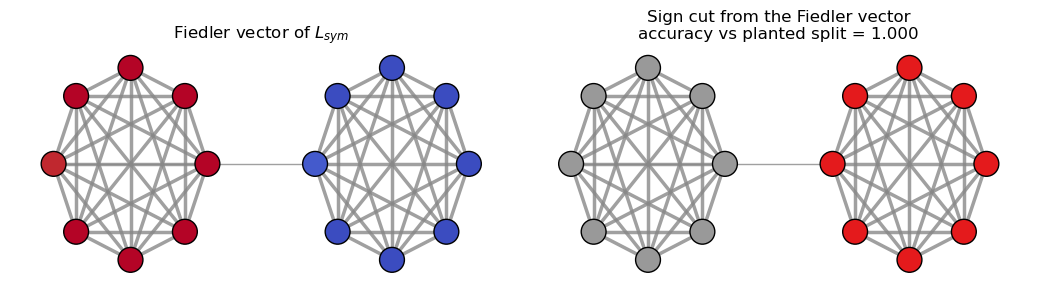

In [27]:

G_two, left_two, right_two, bridge_two = two_cliques_with_bridge(8, 8, bridge_weight=0.4)
nodes_two = left_two + right_two
pos_two = two_clique_positions(left_two, right_two, gap=3.4, radius=1.0)

labels_two, nodes_two_out, vals_two, v2_two = spectral_two_way_lsym(G_two, weight="weight")
true_two = np.array([0] * len(left_two) + [1] * len(right_two))
acc_two = best_binary_alignment(true_two, labels_two)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.0), dpi=100)

draw_graph(
    G_two,
    pos=pos_two,
    ax=ax[0],
    node_values={u: v2_two[i] for i, u in enumerate(nodes_two)},
    node_labels=False,
    node_size=320,
    edge_width_scale=2.5,
)
ax[0].set_title("Fiedler vector of $L_{sym}$")

draw_graph(
    G_two,
    pos=pos_two,
    ax=ax[1],
    node_values={u: labels_two[i] for i, u in enumerate(nodes_two)},
    node_labels=False,
    cmap="Set1",
    vmin=0,
    vmax=1,
    node_size=320,
    edge_width_scale=2.5,
)
ax[1].set_title(f"Sign cut from the Fiedler vector\naccuracy vs planted split = {acc_two:.3f}")

plt.tight_layout()
plt.show()


## 4.2 From one coordinate to many

What if there are $k$ communities, not two?

Then one eigenvector is not enough. We take the first $k$ low-frequency eigenvectors of the normalized Laplacian, use them as coordinates, and then cluster the rows.

The Ng-Jordan-Weiss recipe looks like this:

1. Build $L_{\text{sym}}$.
2. Compute its first $k$ eigenvectors.
3. Put node $i$ at the point given by row $i$ of that eigenvector matrix.
4. Row-normalize.
5. Run $k$-means on those row vectors.

The interesting part is step 3. Spectral clustering is really an **embedding method first** and a **clustering method second**.


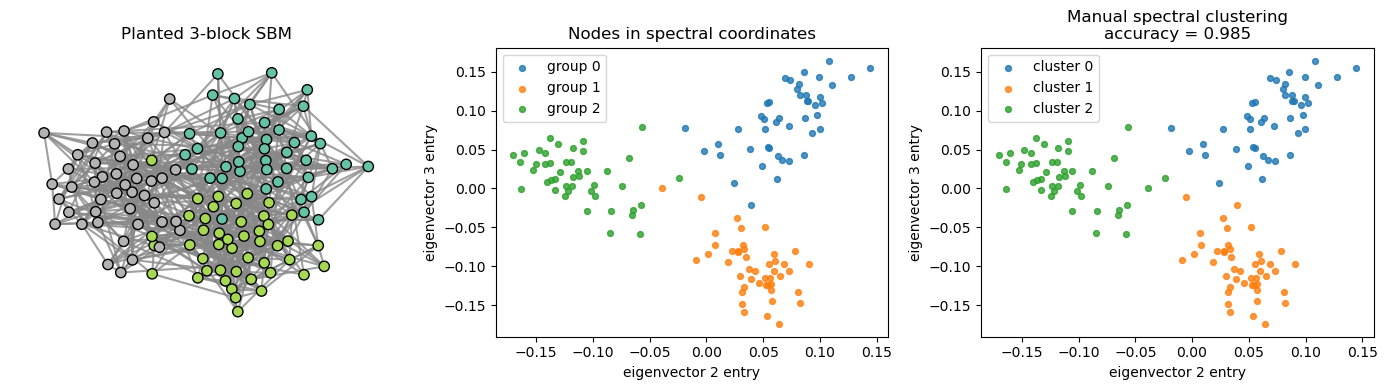

In [28]:

G_sbm, y_sbm = sbm_equal_blocks([45, 45, 45], p_in=0.18, p_out=0.03, seed=5052)
labels_sbm, nodes_sbm, vals_sbm, X_sbm = spectral_clustering_lsym_manual(G_sbm, k=3, seed=5052, n_init=30)
acc_sbm = clustering_accuracy(y_sbm, labels_sbm)

A_sbm, _ = adjacency_sparse(G_sbm)
Lsym_sbm = normalized_laplacian_sym(A_sbm)
vals_plot_sbm, vecs_plot_sbm = eigsh_sorted(Lsym_sbm, k=6, which="SM")

coords_sbm = vecs_plot_sbm[:, 1:3]
pos_sbm = nx.spring_layout(G_sbm, seed=5052)

fig, ax = plt.subplots(1, 3, figsize=(14, 4), dpi=100)

draw_graph(
    G_sbm,
    pos=pos_sbm,
    ax=ax[0],
    node_values={u: y_sbm[i] for i, u in enumerate(nodes_sbm)},
    node_labels=False,
    cmap="Set2",
    vmin=0,
    vmax=2,
    node_size=55,
)
ax[0].set_title("Planted 3-block SBM")

for g in range(3):
    mask = y_sbm == g
    ax[1].scatter(coords_sbm[mask, 0], coords_sbm[mask, 1], s=18, alpha=0.8, label=f"group {g}")
ax[1].set_xlabel(r"eigenvector 2 entry")
ax[1].set_ylabel(r"eigenvector 3 entry")
ax[1].set_title("Nodes in spectral coordinates")
ax[1].legend()

for g in range(3):
    mask = labels_sbm == g
    ax[2].scatter(coords_sbm[mask, 0], coords_sbm[mask, 1], s=18, alpha=0.8, label=f"cluster {g}")
ax[2].set_xlabel(r"eigenvector 2 entry")
ax[2].set_ylabel(r"eigenvector 3 entry")
ax[2].set_title(f"Manual spectral clustering\naccuracy = {acc_sbm:.3f}")
ax[2].legend()

plt.tight_layout()
plt.show()


The graph on the left looks messy. The embedding in the middle does not.

That is the core idea of spectral clustering. We use eigenvectors to move the nodes into a coordinate system where the cluster structure becomes geometrically simple. Then a very plain algorithm like $k$-means is enough.


## 4.3 How many clusters?

One common trick is the **eigengap heuristic**.

Compute a bunch of small eigenvalues of $L_{\text{sym}}$:

$$
0 = \nu_1 \le \nu_2 \le \cdots \le \nu_n.
$$

If there are $k$ well-separated groups, you often see the first $k$ eigenvalues stay relatively small and then a bigger jump after that.

Not a theorem. A heuristic. Still useful.


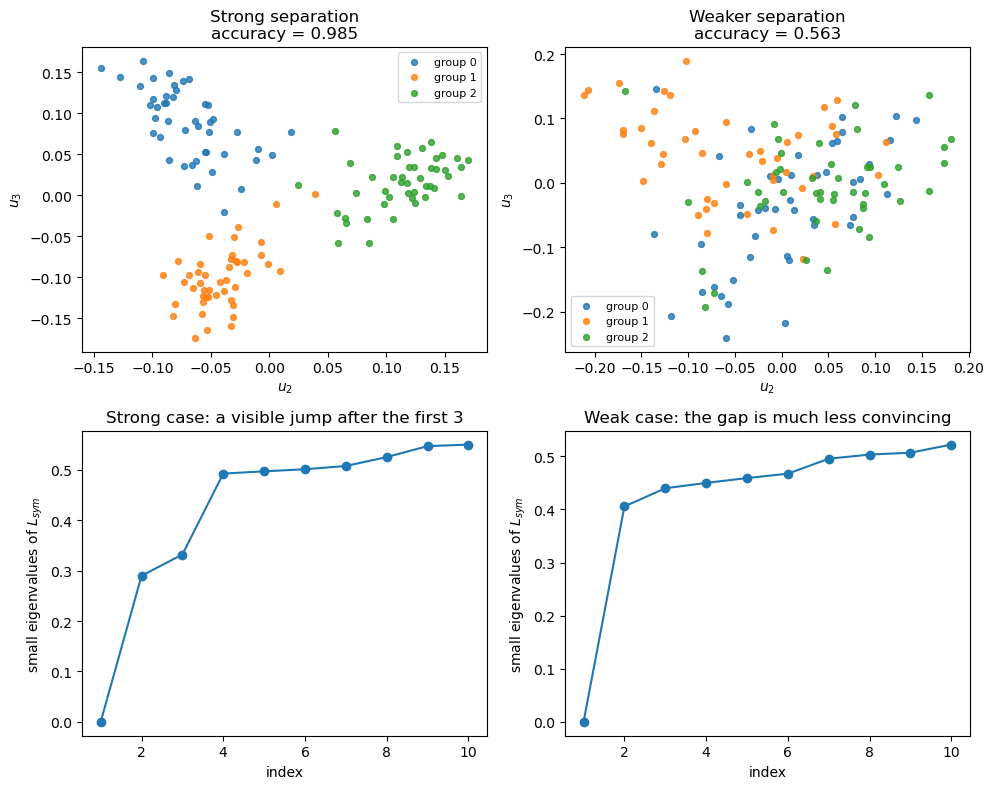

In [29]:

G_strong, y_strong = sbm_equal_blocks([45, 45, 45], p_in=0.18, p_out=0.03, seed=5052)
G_weak, y_weak = sbm_equal_blocks([45, 45, 45], p_in=0.12, p_out=0.05, seed=5052)

def small_laplacian_spectrum(G, k=10):
    A, _ = adjacency_sparse(G)
    Lsym = normalized_laplacian_sym(A)
    vals, vecs = eigsh_sorted(Lsym, k=k, which="SM")
    return vals, vecs

vals_strong, vecs_strong = small_laplacian_spectrum(G_strong, k=10)
vals_weak, vecs_weak = small_laplacian_spectrum(G_weak, k=10)

labels_strong, nodes_strong, vals_sc_strong, X_strong = spectral_clustering_lsym_manual(G_strong, k=3, seed=5052, n_init=30)
labels_weak, nodes_weak, vals_sc_weak, X_weak = spectral_clustering_lsym_manual(G_weak, k=3, seed=5052, n_init=30)

acc_strong = clustering_accuracy(y_strong, labels_strong)
acc_weak = clustering_accuracy(y_weak, labels_weak)

coords_strong = vecs_strong[:, 1:3]
coords_weak = vecs_weak[:, 1:3]

fig, ax = plt.subplots(2, 2, figsize=(10, 8), dpi=100)

for g in range(3):
    mask = y_strong == g
    ax[0, 0].scatter(coords_strong[mask, 0], coords_strong[mask, 1], s=18, alpha=0.8, label=f"group {g}")
ax[0, 0].set_xlabel(r"$u_2$")
ax[0, 0].set_ylabel(r"$u_3$")
ax[0, 0].set_title(f"Strong separation\naccuracy = {acc_strong:.3f}")
ax[0, 0].legend(fontsize=8)

for g in range(3):
    mask = y_weak == g
    ax[0, 1].scatter(coords_weak[mask, 0], coords_weak[mask, 1], s=18, alpha=0.8, label=f"group {g}")
ax[0, 1].set_xlabel(r"$u_2$")
ax[0, 1].set_ylabel(r"$u_3$")
ax[0, 1].set_title(f"Weaker separation\naccuracy = {acc_weak:.3f}")
ax[0, 1].legend(fontsize=8)

ax[1, 0].plot(range(1, 11), vals_strong, marker="o")
ax[1, 0].set_xlabel("index")
ax[1, 0].set_ylabel(r"small eigenvalues of $L_{sym}$")
ax[1, 0].set_title("Strong case: a visible jump after the first 3")

ax[1, 1].plot(range(1, 11), vals_weak, marker="o")
ax[1, 1].set_xlabel("index")
ax[1, 1].set_ylabel(r"small eigenvalues of $L_{sym}$")
ax[1, 1].set_title("Weak case: the gap is much less convincing")

plt.tight_layout()
plt.show()


## 4.4 When spectral clustering is beautiful, and when it is not

It shines when:

- the graph is reasonably assortative,
- the graph is not too sparse,
- degree variation is not doing anything extreme,
- and the graph or similarity matrix is actually the right one.

It struggles when:

- the graph is very sparse,
- clusters overlap,
- a few hubs dominate,
- or the graph you built from the data was a bad graph in the first place.

So when spectral clustering fails, the question is often not *"is spectral clustering bad?"* The better question is *"what geometry did we hand it?"*


## Your turn!

1. In the worked example, keep the block sizes fixed and slowly increase $p_{\text{out}}$. When does the embedding stop looking like three blobs?
2. Try the same experiment with unequal block sizes. Does the eigengap heuristic get easier or harder to read?
3. Remove the row-normalization step before $k$-means. On which graphs does that hurt the most?


# Part 5 — Spectral Embedding and Dimensionality Reduction


## 5.1 Turn eigenvectors into coordinates

Nothing says an eigenvector has to stay "just a signal." We can use it as a coordinate.

In **Laplacian eigenmaps**, node $i$ gets embedded as

$$
i \mapsto (v_2(i), v_3(i), \dots, v_{m+1}(i)),
$$

where $v_k(i)$ means the $i$th entry of eigenvector $v_k$.

Why start at $v_2$? Because $v_1$ is the constant vector. It carries no geometry.

Low-frequency eigenvectors vary smoothly across edges, so nearby nodes get nearby coordinates. That is what makes this a dimensionality-reduction method.


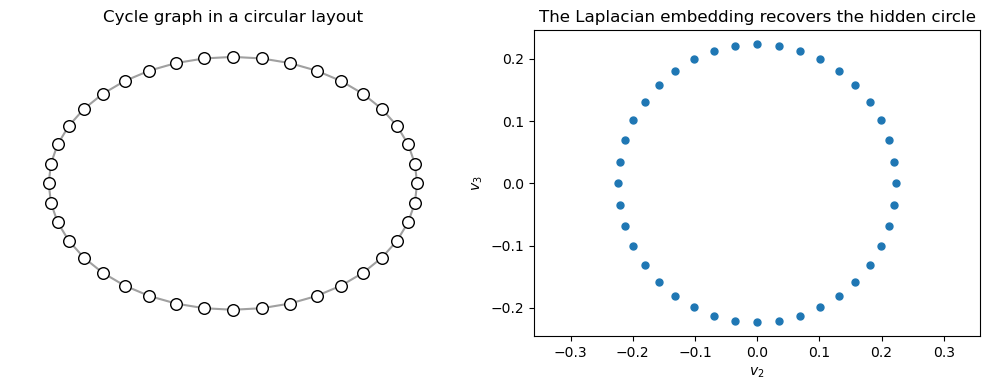

In [30]:

G_cycle_embed = nx.cycle_graph(40)
nodes_cycle_embed = list(G_cycle_embed.nodes())
L_cycle_embed = nx.laplacian_matrix(G_cycle_embed, nodelist=nodes_cycle_embed).toarray()
vals_cycle_embed, vecs_cycle_embed = eigh_sorted(L_cycle_embed)

coords_cycle = vecs_cycle_embed[:, 1:3]
pos_circle = nx.circular_layout(G_cycle_embed)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

draw_graph(
    G_cycle_embed,
    pos=pos_circle,
    ax=ax[0],
    node_labels=False,
    node_size=70,
)
ax[0].set_title("Cycle graph in a circular layout")

ax[1].scatter(coords_cycle[:, 0], coords_cycle[:, 1], s=25)
ax[1].set_xlabel(r"$v_2$")
ax[1].set_ylabel(r"$v_3$")
ax[1].set_title("The Laplacian embedding recovers the hidden circle")
ax[1].axis("equal")

plt.tight_layout()
plt.show()


A cycle has repeated low eigenvalues, so the individual eigenvectors are not unique. They can rotate inside their shared eigenspace.

Still, the **subspace** is right. That is why the 2D spectral embedding still comes out circular.


## 5.2 Why spectral embeddings look like spring layouts

Remember the spring picture from 11a. If every edge is a spring, then drawing a graph is also an energy minimization problem.

Classical spectral drawing fixes the trivial collapse and then chooses coordinates that minimize spring energy. That leads straight to Laplacian eigenvectors.

Force-directed spring layouts use a related but more nonlinear energy with extra repulsion. So the pictures are not identical. Still, they are close cousins.


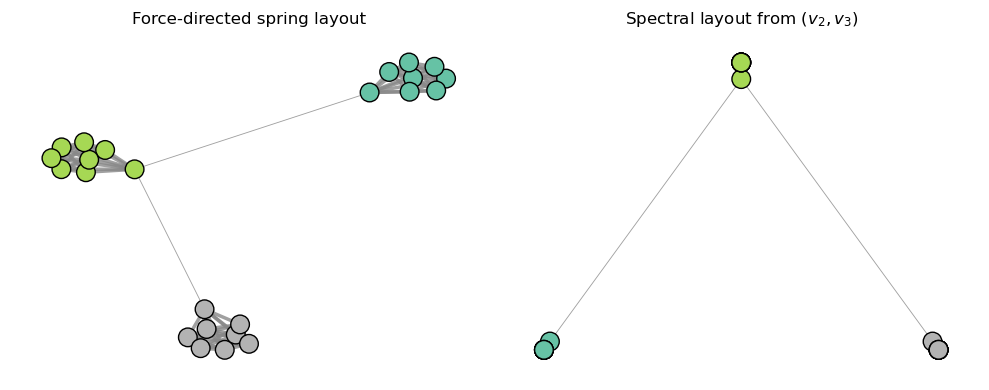

In [31]:

G_draw, groups_draw = clique_chain((8, 8, 8), bridge_weight=0.25)
nodes_draw = sum(groups_draw, [])
L_draw = nx.laplacian_matrix(G_draw, nodelist=nodes_draw, weight="weight").toarray()
vals_draw, vecs_draw = eigh_sorted(L_draw)

spectral_xy = np.column_stack([vecs_draw[:, 1], vecs_draw[:, 2]])
spring_pos = nx.spring_layout(G_draw, seed=5052)
spectral_pos = {u: spectral_xy[i] for i, u in enumerate(nodes_draw)}

group_labels_draw = {}
for g, group in enumerate(groups_draw):
    for u in group:
        group_labels_draw[u] = g

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

draw_graph(
    G_draw,
    pos=spring_pos,
    ax=ax[0],
    node_values=group_labels_draw,
    node_labels=False,
    cmap="Set2",
    vmin=0,
    vmax=2,
    node_size=180,
    edge_width_scale=2.5,
)
ax[0].set_title("Force-directed spring layout")

draw_graph(
    G_draw,
    pos=spectral_pos,
    ax=ax[1],
    node_values=group_labels_draw,
    node_labels=False,
    cmap="Set2",
    vmin=0,
    vmax=2,
    node_size=180,
    edge_width_scale=2.5,
)
ax[1].set_title("Spectral layout from $(v_2, v_3)$")

plt.tight_layout()
plt.show()


## 5.3 Diffusion maps: keep the modes, weight them by time

Random walks give another embedding.

If $\mu_k$ and $\psi_k$ are eigenpairs of a random-walk-type operator, then the diffusion map at time $t$ uses coordinates like

$$
\Phi_t(i) = \big(\mu_2^t \psi_2(i), \mu_3^t \psi_3(i), \dots \big).
$$

Notice the extra factor $\mu_k^t$.

- fast modes, with smaller $|\mu_k|$, get crushed,
- slow modes, with $\mu_k$ close to $1$, survive.

So the time parameter $t$ lets us choose the **scale** of geometry we care about.


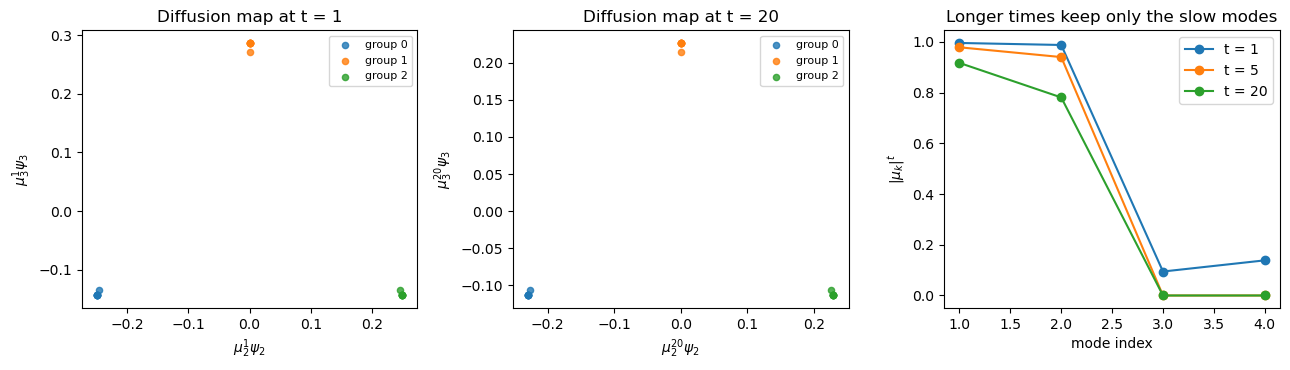

In [32]:

G_dm, groups_dm = clique_chain((8, 8, 8), bridge_weight=0.25)
nodes_dm = sum(groups_dm, [])
group_id_dm = np.concatenate([np.full(len(group), i) for i, group in enumerate(groups_dm)])

A_dm, _ = adjacency_sparse(G_dm, nodelist=nodes_dm, weight="weight")
A_norm_dm = normalized_adjacency(A_dm)

vals_dm, vecs_dm = spla.eigsh(A_norm_dm, k=5, which="LA")
idx_dm = np.argsort(vals_dm)[::-1]
vals_dm = vals_dm[idx_dm]
vecs_dm = vecs_dm[:, idx_dm]

def diffusion_coords(vals, vecs, t):
    return np.column_stack([
        (vals[1] ** t) * vecs[:, 1],
        (vals[2] ** t) * vecs[:, 2],
    ])

coords_t1 = diffusion_coords(vals_dm, vecs_dm, t=1)
coords_t20 = diffusion_coords(vals_dm, vecs_dm, t=20)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), dpi=100)

for g in range(3):
    mask = group_id_dm == g
    ax[0].scatter(coords_t1[mask, 0], coords_t1[mask, 1], s=20, alpha=0.8, label=f"group {g}")
ax[0].set_xlabel(r"$\mu_2^1 \psi_2$")
ax[0].set_ylabel(r"$\mu_3^1 \psi_3$")
ax[0].set_title("Diffusion map at t = 1")
ax[0].legend(fontsize=8)

for g in range(3):
    mask = group_id_dm == g
    ax[1].scatter(coords_t20[mask, 0], coords_t20[mask, 1], s=20, alpha=0.8, label=f"group {g}")
ax[1].set_xlabel(r"$\mu_2^{20} \psi_2$")
ax[1].set_ylabel(r"$\mu_3^{20} \psi_3$")
ax[1].set_title("Diffusion map at t = 20")
ax[1].legend(fontsize=8)

mode_ids = np.arange(1, 5)
for t in [1, 5, 20]:
    ax[2].plot(mode_ids, np.abs(vals_dm[1:5]) ** t, marker="o", label=f"t = {t}")
ax[2].set_xlabel("mode index")
ax[2].set_ylabel(r"$|\mu_k|^t$")
ax[2].set_title("Longer times keep only the slow modes")
ax[2].legend()

plt.tight_layout()
plt.show()


At small $t$, the embedding keeps more detailed structure. At large $t$, the fast modes fade out and the map emphasizes only the slow, global geometry.

That is the core of diffusion maps: geometry through **multi-step connectivity**, not just one-step adjacency.


## 5.4 Family resemblance to t-SNE and UMAP

If you have seen t-SNE or UMAP, the vibe should feel familiar. They also start from local neighborhoods or affinity information and try to preserve nearby relationships in a low-dimensional picture.

But they are **not** Laplacian eigenmaps.

- the objective functions are different,
- the geometry they preserve is different,
- and the optimization stories are different.

Still, the shared idea matters: build a neighborhood graph, then let the graph tell you something about the hidden geometry.


## Your turn!

1. Build a path graph and embed it with $(v_2, v_3)$. What shape do you get?
2. In the diffusion-map example, increase $t$ even more. When does the embedding become almost one-dimensional?
3. Pick your favorite network from an earlier class and compare `nx.spring_layout` with a spectral layout from Laplacian eigenvectors.


# Part 6 — The Non-Backtracking Matrix


## 6.1 The echo problem on sparse graphs

On a sparse graph, ordinary walks have a silly habit:

$$
u \to v \to u.
$$

That immediate reversal is legal for the adjacency matrix and for simple random walks. But it is often not informative. It just echoes the last step back where it came from.

On dense graphs, those echoes get washed out. On very sparse graphs, they can dominate.

That is one reason ordinary adjacency or Laplacian eigenvectors can struggle near the detectability threshold in sparse SBMs: too much of the signal is local, not structural.


## 6.2 The non-backtracking matrix

The **non-backtracking**, or **Hashimoto**, matrix lives on directed edges rather than nodes.

For directed edges $(u \to v)$ and $(x \to y)$,

$$
B_{(u \to v),(x \to y)} =
\begin{cases}
1, & \text{if } v = x \text{ and } y \ne u, \\
0, & \text{otherwise.}
\end{cases}
$$

So you are allowed to keep walking forward, but not to instantly reverse the last edge.


,0->1,1->0,0->2,2->0,1->2,2->1,2->3,3->2
0->1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1->0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0->2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2->0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1->2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2->1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2->3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3->2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


Number of non-backtracking edge-walks of length 2 from (0, 1) to (2, 3): 1


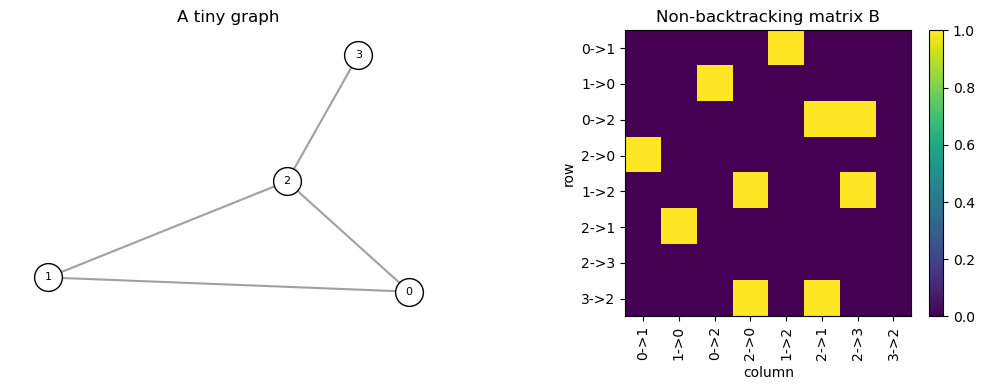

In [33]:

G_nb_small = nx.Graph([(0, 1), (1, 2), (2, 0), (2, 3)])
B_small, dedges_small, idx_small = nonbacktracking_matrix(G_nb_small)

edge_labels = [f"{u}->{v}" for u, v in dedges_small]
B_small_df = pd.DataFrame(B_small.toarray(), index=edge_labels, columns=edge_labels)

display(B_small_df)

e = (0, 1)
f = (2, 3)
count_from_B2 = (B_small @ B_small).toarray()[idx_small[e], idx_small[f]]

print(f"Number of non-backtracking edge-walks of length 2 from {e} to {f}: {int(count_from_B2)}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=100)
draw_graph(G_nb_small, pos=nx.spring_layout(G_nb_small, seed=5052), ax=ax[0], node_labels=True, node_size=400)
ax[0].set_title("A tiny graph")
plot_matrix_heatmap(B_small.toarray(), ax=ax[1], title="Non-backtracking matrix B", xticklabels=edge_labels, yticklabels=edge_labels)
plt.tight_layout()
plt.show()


The matrix is bigger because the states are directed edges, not nodes.

That looks annoying at first. But it buys us something real: the operator keeps moving **forward through structure** instead of bouncing in place.


## 6.3 What does this operator notice?

Two quick checks are surprisingly revealing.

On a tree, non-backtracking walks eventually run out of new directions, so $B$ is nilpotent. Its spectrum collapses to zero.

On a graph with triangles, $\mathrm{tr}(B^3)$ counts closed non-backtracking walks of length $3$, which is $6$ times the number of triangles.

So $B$ really is a walk-counting machine. Just a stricter one.


Largest absolute eigenvalue on a path graph: 0.0
trace(B^3) on a triangle: 6
trace(B^3) on a square: 0
Number of triangles in the triangle graph: 1


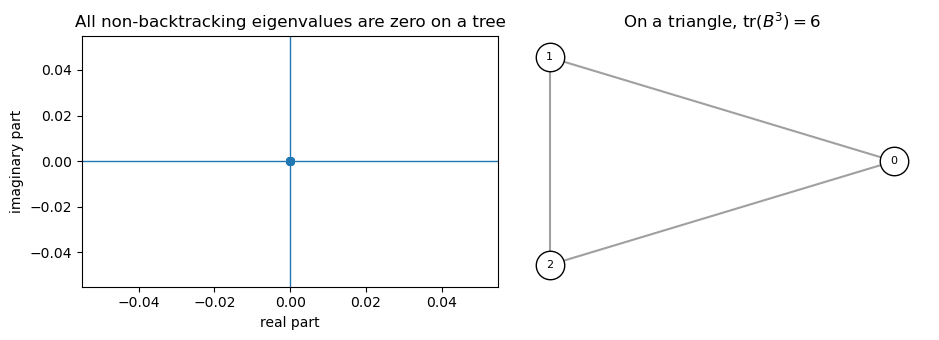

In [34]:

G_tree = nx.path_graph(6)
B_tree, dedges_tree, idx_tree = nonbacktracking_matrix(G_tree)
eig_tree = np.linalg.eigvals(B_tree.toarray())

G_triangle = nx.cycle_graph(3)
B_triangle, _, _ = nonbacktracking_matrix(G_triangle)

G_square = nx.cycle_graph(4)
B_square, _, _ = nonbacktracking_matrix(G_square)

print("Largest absolute eigenvalue on a path graph:", np.max(np.abs(eig_tree)))
print("trace(B^3) on a triangle:", int(np.trace((B_triangle @ B_triangle @ B_triangle).toarray())))
print("trace(B^3) on a square:", int(np.trace((B_square @ B_square @ B_square).toarray())))
print("Number of triangles in the triangle graph:", sum(nx.triangles(G_triangle).values()) // 3)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.5), dpi=100)

ax[0].scatter(eig_tree.real, eig_tree.imag, s=30)
ax[0].axhline(0, linewidth=1)
ax[0].axvline(0, linewidth=1)
ax[0].set_xlabel("real part")
ax[0].set_ylabel("imaginary part")
ax[0].set_title("All non-backtracking eigenvalues are zero on a tree")

draw_graph(G_triangle, pos=nx.circular_layout(G_triangle), ax=ax[1], node_labels=True, node_size=420)
ax[1].set_title(r"On a triangle, $\mathrm{tr}(B^3)=6$")

plt.tight_layout()
plt.show()


## 6.4 The Bethe Hessian: same idea, friendlier matrix

The full non-backtracking matrix is larger than the graph itself.

- node-level matrices are $n \times n$,
- the full non-backtracking matrix is $2m \times 2m$.

That is expensive, and it is non-symmetric.

A very useful symmetric alternative is the **Bethe Hessian**

$$
H(r) = (r^2 - 1)I - rA + D.
$$

Here $r$ is a scale parameter, usually chosen from the degree distribution. In sparse-community settings, this matrix often recovers the same signal as the non-backtracking operator but with ordinary symmetric eigensolvers.


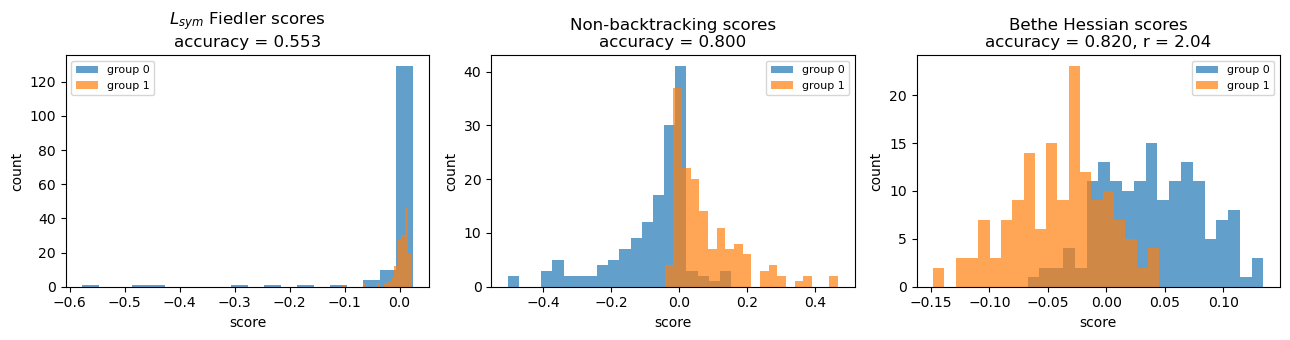

In [35]:

seed_sparse_demo = 29
G_sparse_demo, y_sparse_demo = sbm_two_groups(300, cin=6.2, cout=1.8, seed=seed_sparse_demo)

pred_L_demo, nodes_L_demo, vals_L_demo, score_L_demo = spectral_two_way_lsym(G_sparse_demo)
pred_NB_demo, nodes_NB_demo, vals_NB_demo, score_NB_demo = spectral_two_way_nonbacktracking_full(G_sparse_demo)
pred_BH_demo, nodes_BH_demo, vals_BH_demo, score_BH_demo, r_demo = spectral_two_way_bethe_hessian(G_sparse_demo)

acc_L_demo = best_binary_alignment(y_sparse_demo, pred_L_demo)
acc_NB_demo = best_binary_alignment(y_sparse_demo, pred_NB_demo)
acc_BH_demo = best_binary_alignment(y_sparse_demo, pred_BH_demo)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5), dpi=100)

ax[0].hist(score_L_demo[y_sparse_demo == 0], bins=20, alpha=0.7, label="group 0")
ax[0].hist(score_L_demo[y_sparse_demo == 1], bins=20, alpha=0.7, label="group 1")
ax[0].set_xlabel("score")
ax[0].set_ylabel("count")
ax[0].set_title(f"$L_{{sym}}$ Fiedler scores\naccuracy = {acc_L_demo:.3f}")
ax[0].legend(fontsize=8)

ax[1].hist(score_NB_demo[y_sparse_demo == 0], bins=20, alpha=0.7, label="group 0")
ax[1].hist(score_NB_demo[y_sparse_demo == 1], bins=20, alpha=0.7, label="group 1")
ax[1].set_xlabel("score")
ax[1].set_ylabel("count")
ax[1].set_title(f"Non-backtracking scores\naccuracy = {acc_NB_demo:.3f}")
ax[1].legend(fontsize=8)

ax[2].hist(score_BH_demo[y_sparse_demo == 0], bins=20, alpha=0.7, label="group 0")
ax[2].hist(score_BH_demo[y_sparse_demo == 1], bins=20, alpha=0.7, label="group 1")
ax[2].set_xlabel("score")
ax[2].set_ylabel("count")
ax[2].set_title(f"Bethe Hessian scores\naccuracy = {acc_BH_demo:.3f}, r = {r_demo:.2f}")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


This is the same sparse SBM instance seen three ways.

The ordinary normalized-Laplacian scores are much more entangled. The non-backtracking and Bethe-Hessian scores separate the planted groups much more cleanly.

That is the whole pitch of **spectral redemption**: on sparse graphs, forbid the useless echo and the community signal becomes visible again.


## 6.5 Near the detectability threshold

For the equal-size two-block sparse SBM with edge probabilities $c_{\text{in}}/n$ and $c_{\text{out}}/n$, the Kesten-Stigum line sits at

$$
(c_{\text{in}} - c_{\text{out}})^2 = 2(c_{\text{in}} + c_{\text{out}}).
$$

We'll work just above that line with

$$
c_{\text{in}} = 6.2,
\qquad
c_{\text{out}} = 1.8.
$$

Then

$$
(c_{\text{in}} - c_{\text{out}})^2 = 19.36,
\qquad
2(c_{\text{in}} + c_{\text{out}}) = 16.0.
$$

So recovery should be possible, but not easy. Perfect place to compare methods.


,mean,std
method,,
Bethe Hessian,0.688,0.094
Non-backtracking,0.677,0.087
Adjacency,0.672,0.090
$L_{sym}$,0.624,0.097


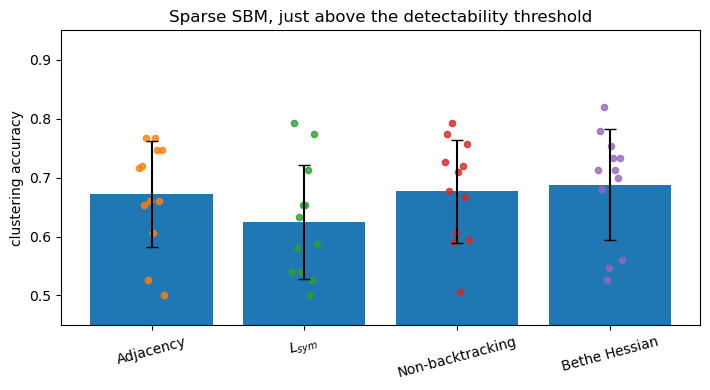

In [36]:

trials = 12
rows = []

for seed in range(trials):
    G_trial, y_trial = sbm_two_groups(300, cin=6.2, cout=1.8, seed=seed)

    pred_A, _, _, _ = spectral_two_way_adjacency(G_trial)
    rows.append({"seed": seed, "method": "Adjacency", "accuracy": best_binary_alignment(y_trial, pred_A)})

    pred_L, _, _, _ = spectral_two_way_lsym(G_trial)
    rows.append({"seed": seed, "method": r"$L_{sym}$", "accuracy": best_binary_alignment(y_trial, pred_L)})

    pred_NB, _, _, _ = spectral_two_way_nonbacktracking_full(G_trial)
    rows.append({"seed": seed, "method": "Non-backtracking", "accuracy": best_binary_alignment(y_trial, pred_NB)})

    pred_BH, _, _, _, _ = spectral_two_way_bethe_hessian(G_trial)
    rows.append({"seed": seed, "method": "Bethe Hessian", "accuracy": best_binary_alignment(y_trial, pred_BH)})

df_sparse_compare = pd.DataFrame(rows)
display(df_sparse_compare.groupby("method")["accuracy"].agg(["mean", "std"]).round(3).sort_values("mean", ascending=False))

methods = ["Adjacency", r"$L_{sym}$", "Non-backtracking", "Bethe Hessian"]
means = [df_sparse_compare.loc[df_sparse_compare["method"] == m, "accuracy"].mean() for m in methods]
stds = [df_sparse_compare.loc[df_sparse_compare["method"] == m, "accuracy"].std() for m in methods]

fig, ax = plt.subplots(1, 1, figsize=(7.2, 4), dpi=100)

xpos = np.arange(len(methods))
ax.bar(xpos, means, yerr=stds, capsize=4)
for i, m in enumerate(methods):
    yvals = df_sparse_compare.loc[df_sparse_compare["method"] == m, "accuracy"].values
    jitter = np.linspace(-0.08, 0.08, len(yvals))
    ax.scatter(np.full_like(yvals, xpos[i], dtype=float) + jitter, yvals, s=20, alpha=0.8)

ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel("clustering accuracy")
ax.set_ylim(0.45, 0.95)
ax.set_title("Sparse SBM, just above the detectability threshold")
plt.tight_layout()
plt.show()


A few things to notice.

- The normalized-Laplacian method is the least reliable in this little near-threshold experiment.
- The Bethe Hessian is the strongest method here.
- The full non-backtracking operator is often competitive too, but on finite graphs a plain adjacency split can still be surprisingly decent.
- The practical lesson is not *"one matrix always wins."* It is that sparse graphs need extra care, and echo-resistant operators become much more attractive there.

That last point is why the Bethe Hessian shows up so often in practice and in modern sparse-graph theory.


## Your turn!

1. Move the sparse SBM **below** the threshold by trying $c_{\text{in}} = 5.8$ and $c_{\text{out}} = 2.2$. What happens to every method?
2. Increase the average degree while keeping the difference $c_{\text{in}} - c_{\text{out}}$ fixed. Which methods improve fastest?
3. Change the demo from two communities to three. Which parts of the non-backtracking story get harder?


# Part 7 — Pitfalls and Practical Advice


## 7.1 Disconnected graphs: there may not be a unique "second eigenvector"

If a graph has $c$ connected components, then $L$ has $c$ zero eigenvalues.

So on a disconnected graph, the whole nullspace comes before anything like a Fiedler direction. In that setting, the phrase *"the second eigenvector"* can stop making sense.

Always check how many zero or near-zero eigenvalues you have before interpreting $v_2$.


## 7.2 Hubs can hijack eigenvectors

Adjacency eigenvectors especially can localize around a few high-degree nodes. When that happens, the eigenvector is telling you more about hubs than about global structure.

Normalizations, regularization, degree-corrected block models, and non-backtracking ideas were invented for a reason.


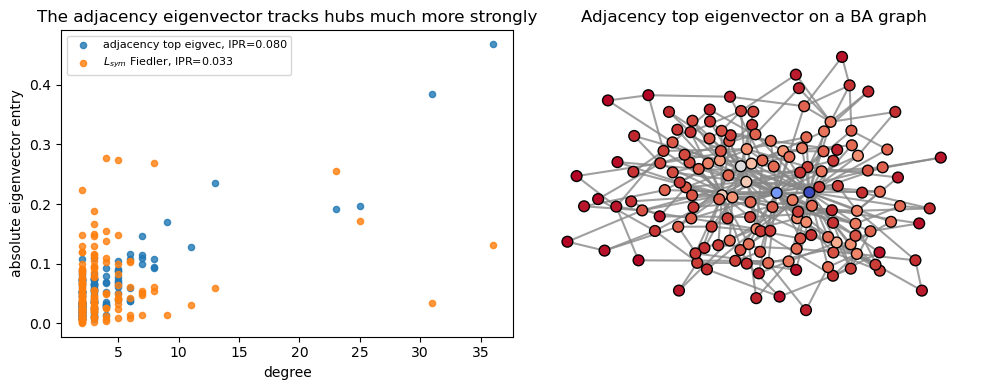

In [37]:

G_ba = nx.barabasi_albert_graph(150, 2, seed=5052)
A_ba, nodes_ba = adjacency_sparse(G_ba)
degrees_ba = degree_vector_from_adjacency(A_ba)

vals_A_ba, vecs_A_ba = spla.eigsh(A_ba, k=3, which="LA")
idx_A_ba = np.argsort(vals_A_ba)[::-1]
vals_A_ba = vals_A_ba[idx_A_ba]
vecs_A_ba = vecs_A_ba[:, idx_A_ba]

vals_L_ba, vecs_L_ba = eigsh_sorted(normalized_laplacian_sym(A_ba), k=3, which="SM")

adj_top = np.abs(vecs_A_ba[:, 0])
lsym_fiedler = np.abs(vecs_L_ba[:, 1])

ipr_adj = inverse_participation_ratio(vecs_A_ba[:, 0])
ipr_lsym = inverse_participation_ratio(vecs_L_ba[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

ax[0].scatter(degrees_ba, adj_top, s=20, alpha=0.8, label=rf"adjacency top eigvec, IPR={ipr_adj:.3f}")
ax[0].scatter(degrees_ba, lsym_fiedler, s=20, alpha=0.8, label=rf"$L_{{sym}}$ Fiedler, IPR={ipr_lsym:.3f}")
ax[0].set_xlabel("degree")
ax[0].set_ylabel("absolute eigenvector entry")
ax[0].set_title("The adjacency eigenvector tracks hubs much more strongly")
ax[0].legend(fontsize=8)

draw_graph(
    G_ba,
    pos=nx.spring_layout(G_ba, seed=5052),
    ax=ax[1],
    node_values={u: vecs_A_ba[i, 0] for i, u in enumerate(nodes_ba)},
    node_labels=False,
    node_size=60,
)
ax[1].set_title("Adjacency top eigenvector on a BA graph")

plt.tight_layout()
plt.show()


## 7.3 Signs and bases are not unique

If $v$ is an eigenvector, then $-v$ is also an eigenvector.

If an eigenvalue has multiplicity larger than $1$, then any orthonormal basis of that eigenspace is valid.

So:

- never treat the overall sign of an eigenvector as meaningful,
- compare partitions or subspaces rather than raw signs,
- be extra careful around repeated or nearly repeated eigenvalues.

The cycle-graph embedding from Part 5 was a good example: the basis can rotate, but the geometric subspace is still right.


## 7.4 Use the right linear algebra

For real networks, the graph matrix is sparse. Store it sparsely and use sparse eigensolvers.

If you only need a few eigenpairs, `scipy.sparse.linalg.eigsh` is the right tool for large symmetric matrices.

Dense eigendecomposition with `np.linalg.eigh` computes **everything**. That is great for toy graphs and terrible for real ones.


,method,time_seconds
0,"sparse eigsh, 5 smallest eigenvalues",0.0232
1,"dense eigh, full spectrum",0.0201


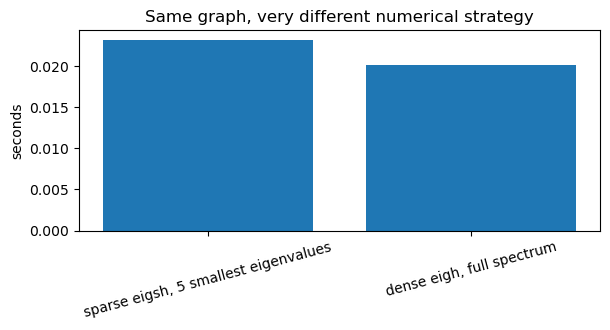

In [38]:

G_time = nx.random_regular_graph(6, 250, seed=5052)
A_time, _ = adjacency_sparse(G_time)
L_time = laplacian_from_adjacency(A_time)

import time

t0 = time.time()
vals_sparse = spla.eigsh(L_time, k=5, which="SM", return_eigenvectors=False)
t_sparse = time.time() - t0

L_dense_time = L_time.toarray()

t0 = time.time()
vals_dense = np.linalg.eigh(L_dense_time)[0]
t_dense = time.time() - t0

timing_df = pd.DataFrame([
    {"method": "sparse eigsh, 5 smallest eigenvalues", "time_seconds": t_sparse},
    {"method": "dense eigh, full spectrum", "time_seconds": t_dense},
])
display(timing_df.round(4))

fig, ax = plt.subplots(1, 1, figsize=(6.2, 3.4), dpi=100)
ax.bar(timing_df["method"], timing_df["time_seconds"])
ax.set_ylabel("seconds")
ax.set_title("Same graph, very different numerical strategy")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## 7.5 Small numerical gotchas that are sometimes super annoying!

A few practical ones:

- **Isolated nodes** make $D^{-1}$ and $D^{-1/2}$ dangerous. Use safe inverses.
- Tiny negative Laplacian eigenvalues are usually **roundoff**, not physics.
- `eigsh` can return eigenvectors with arbitrary sign and arbitrary basis choice inside a nearly repeated eigenspace.
- For non-symmetric operators like the full non-backtracking matrix, **complex eigenvalues are normal**.
- On weighted graphs, always check whether your code is actually using the weights you think it is.


---

# Summary

What to bring back from this notebook:

| Idea | What it tells you |
|:---|:---|
| **$\lambda_2(L)$** | How hard it is to pull a graph into two weakly connected pieces |
| **Fiedler vector** | A soft bottleneck coordinate; sweep it to get an actual cut |
| **Spectral gap** | How fast random walks and other diffusions forget where they started |
| **Diffusion modes** | Small Laplacian eigenvalues control slow global dynamics |
| **Adjacency spectral radius** | Sets mean-field epidemic thresholds and early growth rates |
| **Spectral clustering** | Embed first, cluster second |
| **Laplacian eigenmaps / diffusion maps** | Use eigenvectors as coordinates for geometry and drawing |
| **Non-backtracking / Bethe Hessian** | Fix the echo problem on sparse graphs and rescue weak community signal |

If 11a was about learning what a network spectrum is, 11b is about learning how to read it when something interesting is happening.


# References

The list below is intentionally broad. It is meant to work as both a bibliography and a reading map.

A strong second pass after class is: Fiedler (1973), Chung (1997), Lovász (1993) or Levin–Peres–Wilmer (2017), von Luxburg (2007), Belkin & Niyogi (2003), Coifman & Lafon (2006), Krzakala et al. (2013), Saade et al. (2014), and Pastor-Satorras et al. (2015).


### Foundations of spectral graph theory, Laplacians, and eigenvalue geometry

- **Chung, Fan R. K.** *Spectral Graph Theory*. CBMS Regional Conference Series in Mathematics, no. 92. American Mathematical Society, 1997.  
  Classic short book. Still the cleanest entry point for Laplacians, normalized Laplacians, conductance, and random walks.

- **Brouwer, Andries E., and Willem H. Haemers.** *Spectra of Graphs*. Springer, 2012.  
  Broad reference on adjacency and Laplacian spectra, with many structural examples.

- **Godsil, Chris, and Gordon Royle.** *Algebraic Graph Theory*. Springer, 2001.  
  Strong bridge between graph theory and linear algebra; especially good for spectral intuition.

- **Cvetković, Dragoš, Michael Doob, and Horst Sachs.** *Spectra of Graphs: Theory and Application*. Academic Press, 1980.  
  One of the classic books behind modern graph spectral thinking.

- **Mohar, Bojan.** “The Laplacian Spectrum of Graphs.” In *Graph Theory, Combinatorics, and Applications*, 871–898. Wiley, 1991.  
  A classic survey focused on Laplacians and the structural meaning of their eigenvalues.

- **Spielman, Daniel A.** *Spectral and Algebraic Graph Theory*. Draft book and lecture notes, Yale University, ongoing.  
  Probably the best modern algorithmic exposition of cuts, Laplacians, random walks, and partitioning.

- **Fiedler, Miroslav.** “Algebraic Connectivity of Graphs.” *Czechoslovak Mathematical Journal* 23, no. 2 (1973): 298–305.  
  The original source of algebraic connectivity and the Fiedler vector.

- **Dodziuk, Jozef.** “Difference Equations, Isoperimetric Inequality and Transience of Certain Random Walks.” *Transactions of the American Mathematical Society* 284, no. 2 (1984): 787–794.  
  One of the early papers linking discrete Laplacians, geometry, and isoperimetry.

- **Alon, Noga, and Vitali D. Milman.** “$\lambda_1$, Isoperimetric Inequalities for Graphs, and Superconcentrators.” *Journal of Combinatorial Theory, Series B* 38, no. 1 (1985): 73–88.  
  A landmark paper behind Cheeger-style inequalities in graph form.

- **Newman, Mark.** *Networks*. 2nd ed. Oxford University Press, 2018.  
  Best all-around network-science textbook reference for this notebook.


### Cuts, conductance, spectral partitioning, and clustering

- **Shi, Jianbo, and Jitendra Malik.** “Normalized Cuts and Image Segmentation.” *IEEE Transactions on Pattern Analysis and Machine Intelligence* 22, no. 8 (2000): 888–905.  
  The paper that made normalized cuts and spectral graph partitioning famous in machine learning and vision.

- **Meilă, Marina, and Jianbo Shi.** “A Random Walks View of Spectral Segmentation.” In *Proceedings of AISTATS*, 2001.  
  Excellent bridge from cuts to random-walk interpretations.

- **Ng, Andrew Y., Michael I. Jordan, and Yair Weiss.** “On Spectral Clustering: Analysis and an Algorithm.” In *Advances in Neural Information Processing Systems 14*, 849–856, 2001.  
  The standard eigenvectors-plus-row-normalization-plus-$k$-means recipe.

- **von Luxburg, Ulrike.** “A Tutorial on Spectral Clustering.” *Statistics and Computing* 17, no. 4 (2007): 395–416.  
  Still the canonical tutorial on why the different Laplacians matter and how the algorithm fits together.

- **Newman, M. E. J.** “Spectral Methods for Community Detection and Graph Partitioning.” *Physical Review E* 88, no. 4 (2013): 042822.  
  A network-science oriented treatment of spectral partitioning and community structure.

- **Dall’Amico, Lorenzo, Romain Couillet, and Nicolas Tremblay.** “A Unified Framework for Spectral Clustering in Sparse Graphs.” *Journal of Machine Learning Research* 22 (2021): 1–56.  
  Modern treatment of sparse graphs, regularization, and degree heterogeneity.

- **Mondal, Rahul, Evelina Ignatova, Daniel Walke, David Broneske, Gunter Saake, and Robert Heyer.** “Clustering Graph Data: The Roadmap to Spectral Techniques.” *Discover Artificial Intelligence* 4 (2024): Article 7.  
  Recent survey with a useful taxonomy of spectral-clustering variants.

- **Ding, Ling, Chao Li, Di Jin, and Shifei Ding.** “Survey of Spectral Clustering Based on Graph Theory.” *Pattern Recognition* 151 (2024): 110366.  
  Strong survey of implementation choices: graph construction, Laplacian choice, eigenvector selection, and cluster counting.

- **Berahmand, Kamal, Farid Saberi-Movahed, Razieh Sheikhpour, Yuefeng Li, and Mahdi Jalili.** “A Comprehensive Survey on Spectral Clustering with Graph Structure Learning.” arXiv:2501.13597, 2025.  
  Good current survey on why graph construction is often the real bottleneck.

- **Fortunato, Santo.** “Community Detection in Graphs.” *Physics Reports* 486, no. 3–5 (2010): 75–174.  
  Broad map of community detection, useful when you want context beyond spectral methods.


### Random walks, diffusion, mixing, consensus, and epidemics

- **Lovász, László.** “Random Walks on Graphs: A Survey.” In *Combinatorics, Paul Erdős Is Eighty*, vol. 2, 1–46, 1993.  
  Classic survey on random-walk basics and spectral connections.

- **Doyle, Peter G., and J. Laurie Snell.** *Random Walks and Electric Networks*. Mathematical Association of America, 1984.  
  The classic source for the electrical-network viewpoint on Laplacians and walks.

- **Levin, David A., Yuval Peres, and Elizabeth L. Wilmer.** *Markov Chains and Mixing Times*. 2nd ed. American Mathematical Society, 2017.  
  Gold-standard text on mixing, spectral gap, and convergence rates.

- **Masuda, Naoki, Mason A. Porter, and Renaud Lambiotte.** “Random Walks and Diffusion on Networks.” *Physics Reports* 716–717 (2017): 1–58.  
  Broad, modern review of diffusion-style dynamics on networks.

- **Chung, Fan.** “Random Walks and Local Cuts in Graphs.” *Linear Algebra and its Applications* 423, no. 1 (2007): 22–32.  
  Nice source for local partitioning and random-walk views of cuts.

- **Olfati-Saber, Reza, J. Alex Fax, and Richard M. Murray.** “Consensus and Cooperation in Networked Multi-Agent Systems.” *Proceedings of the IEEE* 95, no. 1 (2007): 215–233.  
  Classic consensus reference. Connects directly to Laplacian dynamics.

- **Van Mieghem, Piet, Jasmina Omic, and Robert Kooij.** “Virus Spread in Networks.” *IEEE/ACM Transactions on Networking* 17, no. 1 (2009): 1–14.  
  Standard reference for the adjacency spectral radius and mean-field epidemic thresholds.

- **Pastor-Satorras, Romualdo, Claudio Castellano, Piet Van Mieghem, and Alessandro Vespignani.** “Epidemic Processes in Complex Networks.” *Reviews of Modern Physics* 87, no. 3 (2015): 925–979.  
  Deep review of epidemic models, threshold results, and when approximations succeed or fail.

- **Ganesh, Ankur, Laurent Massoulié, and Don Towsley.** “The Effect of Network Topology on the Spread of Epidemics.” In *Proceedings of IEEE INFOCOM*, 2005.  
  Early influential paper on how network structure changes epidemic behavior.


### Embeddings, graph signal processing, and spectral machine learning

- **Belkin, Mikhail, and Partha Niyogi.** “Laplacian Eigenmaps for Dimensionality Reduction and Data Representation.” *Neural Computation* 15, no. 6 (2003): 1373–1396.  
  The foundational reference for Laplacian eigenmaps.

- **Coifman, Ronald R., and Stéphane Lafon.** “Diffusion Maps.” *Applied and Computational Harmonic Analysis* 21, no. 1 (2006): 5–30.  
  The original diffusion-maps paper.

- **Shuman, David I., Sunil K. Narang, Pascal Frossard, Antonio Ortega, and Pierre Vandergheynst.** “The Emerging Field of Signal Processing on Graphs.” *IEEE Signal Processing Magazine* 30, no. 3 (2013): 83–98.  
  Great first stop for graph Fourier ideas, filtering, and smoothness.

- **Sandryhaila, Aliaksei, and José M. F. Moura.** “Discrete Signal Processing on Graphs.” *IEEE Transactions on Signal Processing* 61, no. 7 (2013): 1644–1656.  
  Another major graph-signal-processing reference.

- **Bruna, Joan, Wojciech Zaremba, Arthur Szlam, and Yann LeCun.** “Spectral Networks and Locally Connected Networks on Graphs.” arXiv:1312.6203, 2014.  
  Early spectral neural-network paper; useful for seeing how these ideas entered graph ML.

- **Kipf, Thomas N., and Max Welling.** “Semi-Supervised Classification with Graph Convolutional Networks.” arXiv:1609.02907, 2017.  
  A modern descendant of Laplacian smoothing ideas.

- **van der Maaten, Laurens, and Geoffrey Hinton.** “Visualizing Data Using t-SNE.” *Journal of Machine Learning Research* 9 (2008): 2579–2605.  
  Not a spectral method, but useful for comparing neighborhood-based embedding philosophies.

- **McInnes, Leland, John Healy, and James Melville.** “UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.” arXiv:1802.03426, 2018.  
  Also not a spectral method, but strongly related in spirit through graph-based local geometry.


### Sparse graphs, stochastic block models, localization, non-backtracking operators, and the Bethe Hessian

- **Holland, Paul W., Kathryn B. Laskey, and Samuel Leinhardt.** “Stochastic Blockmodels: First Steps.” *Social Networks* 5, no. 2 (1983): 109–137.  
  The original stochastic block model paper.

- **Karrer, Brian, and M. E. J. Newman.** “Stochastic Blockmodels and Community Structure in Networks.” *Physical Review E* 83, no. 1 (2011): 016107.  
  Introduces the degree-corrected SBM. Very relevant whenever degree heterogeneity matters.

- **Decelle, Aurélien, Florent Krzakala, Cristopher Moore, and Lenka Zdeborová.** “Asymptotic Analysis of the Stochastic Block Model for Modular Networks and Its Algorithmic Applications.” *Physical Review E* 84, no. 6 (2011): 066106.  
  The cavity-method paper behind detectability thresholds and the Kesten–Stigum picture.

- **Abbe, Emmanuel.** “Community Detection and Stochastic Block Models: Recent Developments.” *Journal of Machine Learning Research* 18, no. 177 (2018): 1–86.  
  Excellent survey of SBM thresholds, algorithms, and recovery notions.

- **Hashimoto, Ki-ichiro.** “Zeta Functions of Finite Graphs and Representations of $p$-Adic Groups.” In *Advances in Studies in Pure Mathematics* 15 (1989): 211–280.  
  Historical source for the non-backtracking operator.

- **Bass, Hyman.** “The Ihara-Selberg Zeta Function of a Tree Lattice.” *International Journal of Mathematics* 3, no. 6 (1992): 717–797.  
  Classical reference connecting non-backtracking walks and graph zeta functions.

- **Krzakala, Florent, Cristopher Moore, Elchanan Mossel, Joe Neeman, Allan Sly, Lenka Zdeborová, and Pan Zhang.** “Spectral Redemption in Clustering Sparse Networks.” *Proceedings of the National Academy of Sciences* 110, no. 52 (2013): 20935–20940.  
  The paper that made non-backtracking spectral methods famous in sparse community detection.

- **Saade, Alaa, Florent Krzakala, and Lenka Zdeborová.** “Spectral Clustering of Graphs with the Bethe Hessian.” In *Advances in Neural Information Processing Systems 27*, 2014.  
  Introduces the Bethe Hessian as a symmetric alternative to the full non-backtracking operator.

- **Bordenave, Charles, Marc Lelarge, and Laurent Massoulié.** “Non-backtracking Spectrum of Random Graphs: Community Detection and Non-Regular Ramanujan Graphs.” *Annals of Probability* 46, no. 1 (2018): 1–71.  
  Rigorous spectral theory behind non-backtracking operators on sparse random graphs.

- **Martin, Travis, Xiao Zhang, and M. E. J. Newman.** “Localization and Centrality in Networks.” *Physical Review E* 90, no. 5 (2014): 052808.  
  Useful for understanding eigenvector localization and why hubs can hijack spectral methods.


### Software references and practical sources

- **NetworkX Developers.** *NetworkX Documentation*, stable release, accessed 2026.  
  Used in this notebook for graph construction, adjacency matrices, Laplacians, and layouts.

- **SciPy Developers.** *SciPy Documentation*, stable release, accessed 2026.  
  Used here for matrix exponentials, sparse matrices, `eigsh`, and `eigs`.

- **NumPy Developers.** *NumPy Documentation*, stable release, accessed 2026.  
  Core numerical array library for everything in the notebook.

- **Matplotlib Developers.** *Matplotlib Documentation*, stable release, accessed 2026.  
  Plotting and visualization reference.

- **Mahoney, Michael W.** *Lecture Notes on Spectral Graph Methods*. arXiv:1608.04845, 2016.  
  Helpful bridge between theory, algorithms, and machine-learning applications.

- **Trevisan, Luca.** *Lecture Notes on Expansion, Sparsest Cut, and Spectral Graph Theory*, 2016.  
  Good algorithmic supplement if you want more on Cheeger-style guarantees and partitioning.
